# Arabic AI Voice Agent for Saudi Labor Law  
## Stage 02 — Data Preparation and Knowledge Base Construction

This notebook implements the second stage of the project: preparing the legal and FAQ datasets for a Retrieval-Augmented Generation (RAG) system. The objective is to transform the raw scraped data into a clean, auditable, and evaluation-safe knowledge base that can later be indexed using embeddings and a vector database.

A key methodological decision in this stage is to separate **legal completeness** from **retrieval safety**. All cleaned legal article records are preserved for auditability, including repealed articles and valid legal variants. However, only active legal articles are allowed into the experimental RAG knowledge base. This prevents the system from retrieving outdated or repealed legal provisions when answering users.

**Inputs:** Raw scraping outputs stored under `saudi_labor_law_voice_agent_project/01_raw/`  
**Outputs:** Clean datasets, safe RAG knowledge bases, evaluation datasets, chunk files, quality reports, and academic visualisations.


## Stage 00 — Project Setup

This stage defines the project directory structure, imports the required Python libraries, and prepares the folders used throughout the data preparation pipeline.

The setup cell should be executed once at the beginning of the notebook. It ensures that all subsequent outputs are stored in a consistent and reproducible project structure.


In [1]:
# =========================================================
# Stage 00 - Project Setup
# =========================================================

# أول مرة فقط إذا احتجت:
# !pip install pandas openpyxl numpy scikit-learn matplotlib
# اختياري لتحسين عرض العربية في الرسوم:
# !pip install arabic-reshaper python-bidi

import os
import re
import json
import shutil
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_DIR = Path("saudi_labor_law_voice_agent_project")
RAW_DIR = PROJECT_DIR / "01_raw"
CLEAN_DIR = PROJECT_DIR / "02_clean"
FINAL_DIR = PROJECT_DIR / "03_final"
CHUNKS_DIR = PROJECT_DIR / "04_chunks"
REPORTS_DIR = PROJECT_DIR / "05_reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for folder in [RAW_DIR, CLEAN_DIR, FINAL_DIR, CHUNKS_DIR, REPORTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# محاولة اختيار خط يدعم العربية إن كان متاحاً على الجهاز
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = ["Tahoma", "Arial", "DejaVu Sans"]

print("Project folder is ready:", PROJECT_DIR.resolve())
print("Raw data folder:", RAW_DIR.resolve())
print("Figures folder:", FIGURES_DIR.resolve())

Project folder is ready: C:\Users\PC\Desktop\data collection code\saudi_labor_law_voice_agent_project
Raw data folder: C:\Users\PC\Desktop\data collection code\saudi_labor_law_voice_agent_project\01_raw
Figures folder: C:\Users\PC\Desktop\data collection code\saudi_labor_law_voice_agent_project\05_reports\figures


## Stage 01 — Input File Configuration

This stage defines the expected raw input files produced by the web scraping notebook. The files may be placed either in the same directory as this notebook or inside the project raw-data folder.

The notebook expects two main sources:

1. Saudi Labor Law articles scraped from the official HRSD source.
2. Classified HRSD FAQ records containing questions, answers, and filter metadata.

This step also defines the FAQ evaluation split ratio used later to prevent data leakage between indexing and evaluation.


In [2]:
# =========================================================
# Stage 01 - Input Files
# =========================================================

LABOR_ARTICLES_FILENAME = "saudi_labor_law_by_bab_articles.csv"
FAQ_CLASSIFIED_FILENAME = "hrsd_faq_with_filters_classification.csv"

# نسبة أسئلة FAQ التي سنتركها للتقييم لمنع تسريب البيانات في التجربة
FAQ_EVAL_RATIO = 0.30
RANDOM_SEED = 42


def find_input_file(filename, search_roots=None):
    """Find a file in the final scraping output folder first, then fallback to common locations."""
    if search_roots is None:
        search_roots = [
            RAW_DIR,
            PROJECT_DIR / "01_raw",
            Path.cwd() / "saudi_labor_law_voice_agent_project" / "01_raw",
            Path.cwd() / "01_raw",
            Path.cwd(),
            PROJECT_DIR,
            Path.cwd() / "data",
        ]

    checked = []
    for root in search_roots:
        candidate = root / filename
        checked.append(str(candidate))
        if candidate.exists():
            return candidate

    # last resort: recursive search in current directory
    for candidate in Path.cwd().glob(f"**/{filename}"):
        if candidate.is_file():
            return candidate

    raise FileNotFoundError(
        f"لم أجد الملف: {filename}\n"
        f"ضع مخرجات مرحلة السحب داخل: {RAW_DIR.resolve()}\n\n"
        f"المسارات التي تم فحصها:\n" + "\n".join(checked)
    )


LABOR_ARTICLES_FILE = find_input_file(LABOR_ARTICLES_FILENAME)
FAQ_CLASSIFIED_FILE = find_input_file(FAQ_CLASSIFIED_FILENAME)

# نسخ نسخة من الملفات الخام داخل 01_raw للتوثيق، بدون إعادة سحب من الموقع
for src in [LABOR_ARTICLES_FILE, FAQ_CLASSIFIED_FILE]:
    dst = RAW_DIR / src.name
    if src.resolve() != dst.resolve():
        shutil.copy2(src, dst)

print("Labor articles file:", LABOR_ARTICLES_FILE)
print("FAQ classified file:", FAQ_CLASSIFIED_FILE)
print("Raw files are available in:", RAW_DIR.resolve())

Labor articles file: saudi_labor_law_voice_agent_project\01_raw\saudi_labor_law_by_bab_articles.csv
FAQ classified file: saudi_labor_law_voice_agent_project\01_raw\hrsd_faq_with_filters_classification.csv
Raw files are available in: C:\Users\PC\Desktop\data collection code\saudi_labor_law_voice_agent_project\01_raw


## Stage 02 — Load Raw Scraped Data

This stage loads the raw legal article dataset and the classified FAQ dataset exactly as produced by the scraping stage.

The goal is not to transform the data yet, but to verify that the raw files are readable and that their initial shapes are available for later comparison during the cleaning and validation stages.


In [3]:
# =========================================================
# Stage 02 - Load Scraped Data
# =========================================================

df_articles_raw = pd.read_csv(LABOR_ARTICLES_FILE, encoding="utf-8-sig")
df_faq_raw = pd.read_csv(FAQ_CLASSIFIED_FILE, encoding="utf-8-sig")

print("Articles raw shape:", df_articles_raw.shape)
print("FAQ raw shape:", df_faq_raw.shape)

print("\nArticles columns:")
print(list(df_articles_raw.columns))

print("\nFAQ columns:")
print(list(df_faq_raw.columns))

display(df_articles_raw.head(3))
display(df_faq_raw.head(3))

Articles raw shape: (249, 13)
FAQ raw shape: (711, 10)

Articles columns:
['bab_order', 'bab_label', 'bab_title', 'fasl', 'article_title', 'article_number', 'article_number_label', 'article_number_int', 'article_text', 'source_url', 'searchable_text', 'text_len', 'article_status']

FAQ columns:
['faq_id', 'question', 'answer', 'beneficiaries', 'sector', 'subsite', 'page_number', 'page_url', 'source', 'searchable_text']


,bab_order,bab_label,bab_title,fasl,article_title,article_number,article_number_label,article_number_int,article_text,source_url,searchable_text,text_len,article_status
0,1,الباب الأول,التعريفات / الأحكام العامة,الفصل الأول,المادة الأولى:,الأولى,1,1,يسمى هذا النظام نظام العمل.,https://www.hrsd.gov.sa/node/5575978,الباب الأول - التعريفات / الأحكام العامة - الفصل الأول - المادة الأولى: - يسمى هذا النظام نظام العمل.,27,active
1,1,الباب الأول,التعريفات / الأحكام العامة,الفصل الأول,المادة الثانية :,الثانية,2,2,يقصد بالألفاظ والعبارات الآتية – أينما وردت في هذا النظام – المعاني المبينة أمامها ما لم يقتض السياق خلاف ذلك: -الوزارة: وزارة الموارد البشرية والتنمية الاجتماعية. -الوزير: وزي...,https://www.hrsd.gov.sa/node/5575978,الباب الأول - التعريفات / الأحكام العامة - الفصل الأول - المادة الثانية : - يقصد بالألفاظ والعبارات الآتية – أينما وردت في هذا النظام – المعاني المبينة أمامها ما لم يقتض السياق...,3519,active
2,1,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة الثالثة:,الثالثة,3,3,العمل حق للمواطن ، لا يجوز لغيره ممارسته إلا بعد توافر الشروط المنصوص عليها في هذا النظام ، والمواطنون متساوون في حق العمل دون أي تمييز على أساس الجنس أو الإعاقة أو السن أو أي ...,https://www.hrsd.gov.sa/node/5575978,الباب الأول - التعريفات / الأحكام العامة - الفصل الثاني - المادة الثالثة: - العمل حق للمواطن ، لا يجوز لغيره ممارسته إلا بعد توافر الشروط المنصوص عليها في هذا النظام ، والمواطن...,258,active


,faq_id,question,answer,beneficiaries,sector,subsite,page_number,page_url,source,searchable_text
0,1,هل تستخدم البوابة والانظمة التابعة لها الحلول الوطنية eSignature؟,"تقدم الوزارة خدمة التوقيع الالكتروني في اطار ادارة وتوثيق عقود العمل عبر منصة ""قوى"" يمكن للمنشآت انشاء وتوثيق وانهاء عقود العمل للموظفين بشكل الكرتوني بالكامل.",أصحاب عمل | أفراد | العمالة المنزلية | كبار السن,قطاع العمل,مركز الرياض للسياسات السلوكية,1,https://www.hrsd.gov.sa/contact-us/faq,HRSD FAQ,التصنيف: أصحاب عمل | أفراد | العمالة المنزلية | كبار السن قطاع العمل مركز الرياض للسياسات السلوكية السؤال: هل تستخدم البوابة والانظمة التابعة لها الحلول الوطنية eSignature؟ الإ...
1,2,ماذا أفعل إذا تم إرجاع الطلب للمراجعة؟,الدخول إلى “مهامي” ← اختيار مهمة طلب مراجعة ← تعديل البيانات ← إعادة الإرسال.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية,1,https://www.hrsd.gov.sa/contact-us/faq,HRSD FAQ,التصنيف: التخصصات الاجتماعية | العمالة المنزلية | كبار السن قطاع التنمية الاجتماعية مركز الرياض للسياسات السلوكية السؤال: ماذا أفعل إذا تم إرجاع الطلب للمراجعة؟ الإجابة: الدخول...
2,3,ماذا يحدث بعد إرسال الطلب؟,يتم تحويل الطلب إلى اللجنة للمراجعة ويتم إشعار المتقدم بحالة الطلب.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية,1,https://www.hrsd.gov.sa/contact-us/faq,HRSD FAQ,التصنيف: التخصصات الاجتماعية | العمالة المنزلية | كبار السن قطاع التنمية الاجتماعية مركز الرياض للسياسات السلوكية السؤال: ماذا يحدث بعد إرسال الطلب؟ الإجابة: يتم تحويل الطلب إل...


## Stage 03 — Arabic Text Cleaning Utilities

This stage defines reusable helper functions for cleaning Arabic legal and FAQ text.

The cleaning process is designed to be conservative: it removes noise such as extra spaces, unnecessary symbols, and formatting artefacts while preserving the legal meaning of the original text. A separate indexing-friendly version of the text is later created for retrieval purposes.


In [4]:
# =========================================================
# Stage 03 - Arabic Text Cleaning Helpers
# =========================================================

ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
TATWEEL = "\u0640"


def clean_basic_text(text):
    """
    تنظيف محافظ لا يغيّر معنى النص القانوني.
    نستخدمه للنصوص الأصلية والأعمدة العامة.
    """
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("\u200f", " ")
    text = text.replace("\u200e", " ")
    text = text.replace("\ufeff", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_arabic_for_search(text):
    """
    نسخة مخصصة للفهرسة/البحث فقط، وليست بديلاً عن النص القانوني الأصلي.
    """
    text = clean_basic_text(text)
    text = text.replace(TATWEEL, "")
    text = ARABIC_DIACRITICS.sub("", text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r"[^\u0600-\u06FFa-zA-Z0-9\s،؛؟:.,()\-/%]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def safe_col(df, col, default=""):
    """Create missing column if not found."""
    if col not in df.columns:
        df[col] = default
    return df


def make_hash(*values):
    """Stable id for records/chunks."""
    raw = "|||".join(clean_basic_text(v) for v in values)
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()


def deterministic_split_by_hash(value, eval_ratio=0.20):
    """
    Deterministic split without random leakage.
    Returns True if record should go to evaluation.
    """
    h = hashlib.md5(str(value).encode("utf-8")).hexdigest()
    bucket = int(h[:8], 16) / 0xFFFFFFFF
    return bucket < eval_ratio

## Stage 04 — Clean Saudi Labor Law Articles

This stage cleans the legal article dataset while preserving legal auditability.

Repealed articles are **not deleted** at this stage. Instead, they are explicitly labelled using the `article_status` field. This design keeps the cleaned legal dataset complete for documentation and audit purposes, while allowing later stages to safely exclude repealed provisions from RAG indexing.

The cleaned legal dataset therefore supports two goals:

1. Maintaining a complete legal audit dataset.
2. Building a safe retrieval knowledge base using active articles only.


In [5]:
# =========================================================
# Stage 04 - Clean Legal Articles
# الاحتفاظ بالمواد الملغاة ومواد "مكرر" لأنها مهمة قانونياً
# =========================================================

df_articles = df_articles_raw.copy()

required_article_cols = [
    "bab_order", "bab_label", "bab_title", "fasl",
    "article_title", "article_number", "article_number_label",
    "article_number_int", "article_text", "source_url"
]

for col in required_article_cols:
    df_articles = safe_col(df_articles, col, "")

# تنظيف محافظ للأعمدة النصية
for col in required_article_cols:
    df_articles[col] = df_articles[col].apply(clean_basic_text)

# إذا لم يكن article_number_label متوفراً بشكل جيد، نستخدم article_number كبديل
df_articles["article_number_label"] = np.where(
    df_articles["article_number_label"].astype(str).str.strip().eq(""),
    df_articles["article_number"],
    df_articles["article_number_label"],
)

# تحويل الرقم إلى قيمة رقمية مع الاحتفاظ بالنسخة النصية القانونية في article_number_label
df_articles["article_number_int"] = pd.to_numeric(df_articles["article_number_int"], errors="coerce")

# تنظيف نص المادة مع إزالة التطويل فقط، بدون حذف المواد القصيرة
before_raw_rows = len(df_articles)
df_articles["article_text"] = (
    df_articles["article_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"[ـ]+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_articles["text_len"] = df_articles["article_text"].str.len()

# تصنيف حالة المادة
df_articles["article_status"] = df_articles["article_text"].apply(
    lambda x: "repealed" if ("ملغاة" in x or "ملغى" in x) else "active"
)

# حذف الصفوف الفارغة فقط، وليس المواد القصيرة مثل "ملغاة"
df_articles = df_articles[df_articles["article_text"].str.len() > 0].copy()
before_dedup_rows = len(df_articles)

# إزالة التكرار الحقيقي حسب article_number_label، مع الاحتفاظ بأطول نص لنفس المادة إن تكرر نفس label فعلاً
df_articles = (
    df_articles
    .sort_values(["article_number_label", "text_len"], ascending=[True, False])
    .drop_duplicates(subset=["article_number_label"], keep="first")
    .sort_values(["article_number_int", "article_number_label"], na_position="last")
    .reset_index(drop=True)
)

# Metadata

df_articles["source_type"] = "legal_article"
df_articles["source_name"] = "نظام العمل السعودي"
df_articles["legal_category"] = df_articles["bab_title"].replace("", np.nan).fillna("نظام العمل")

df_articles["document_unit_id"] = df_articles.apply(
    lambda r: make_hash(
        r["source_type"],
        r["article_number_label"],
        r["article_title"],
        r["article_text"]
    ),
    axis=1
)

df_articles["text_for_indexing"] = df_articles.apply(
    lambda r: clean_basic_text(
        f"المصدر: {r['source_name']}\n"
        f"{r['bab_label']} - {r['bab_title']}\n"
        f"{r['fasl']}\n"
        f"{r['article_title']}\n"
        f"رقم المادة: {r['article_number_label']}\n"
        f"حالة المادة: {r['article_status']}\n"
        f"النص: {r['article_text']}"
    ),
    axis=1
)

df_articles["normalized_text"] = df_articles["text_for_indexing"].apply(normalize_arabic_for_search)

# حفظ النسخة النظيفة

df_articles.to_csv(CLEAN_DIR / "clean_labor_law_articles.csv", index=False, encoding="utf-8-sig")
df_articles.to_excel(CLEAN_DIR / "clean_labor_law_articles.xlsx", index=False)

# فحوصات مهمة
valid_nums = df_articles["article_number_int"].dropna().astype(int)
nums = set(valid_nums)
max_num = max(nums) if nums else 0
missing_numeric_articles = [n for n in range(1, max_num + 1) if n not in nums]
true_duplicate_labels = int(df_articles["article_number_label"].duplicated().sum())
repeated_numeric_numbers = int(df_articles["article_number_int"].duplicated().sum())

print("Articles raw rows:", before_raw_rows)
print("Articles after empty-text filter:", before_dedup_rows)
print("Legal article records after true deduplication:", len(df_articles))
print("Unique numeric article numbers:", len(nums), "| max:", max_num)
print("Missing numeric article numbers:", missing_numeric_articles)
print("True duplicated article labels:", true_duplicate_labels)
print("Repeated numeric numbers, often legal 'مكرر' articles:", repeated_numeric_numbers)
print("Empty article_text:", int((df_articles["article_text"].astype(str).str.strip() == "").sum()))

print("\nArticle status distribution:")
display(df_articles["article_status"].value_counts().to_frame("count"))

print("\nShort non-repealed articles. This should usually contain only very short valid articles such as Article 1:")
display(
    df_articles[
        (df_articles["text_len"] < 30) &
        (df_articles["article_status"] != "repealed")
    ][["article_number_label", "article_title", "article_text", "text_len", "article_status"]]
)

display(df_articles[[
    "bab_label", "bab_title", "fasl", "article_title",
    "article_number_label", "article_status", "article_text"
]].head(10))

Articles raw rows: 249
Articles after empty-text filter: 249
Legal article records after true deduplication: 249
Unique numeric article numbers: 245 | max: 245
Missing numeric article numbers: []
True duplicated article labels: 0
Repeated numeric numbers, often legal 'مكرر' articles: 4
Empty article_text: 0

Article status distribution:


,count
article_status,
active,211
repealed,38



Short non-repealed articles. This should usually contain only very short valid articles such as Article 1:


,article_number_label,article_title,article_text,text_len,article_status
0,1,المادة الأولى:,يسمى هذا النظام نظام العمل.,27,active


,bab_label,bab_title,fasl,article_title,article_number_label,article_status,article_text
0,الباب الأول,التعريفات / الأحكام العامة,الفصل الأول,المادة الأولى:,1,active,يسمى هذا النظام نظام العمل.
1,الباب الأول,التعريفات / الأحكام العامة,الفصل الأول,المادة الثانية :,2,active,يقصد بالألفاظ والعبارات الآتية – أينما وردت في هذا النظام – المعاني المبينة أمامها ما لم يقتض السياق خلاف ذلك: -الوزارة: وزارة الموارد البشرية والتنمية الاجتماعية. -الوزير: وزي...
2,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة الثالثة:,3,active,العمل حق للمواطن ، لا يجوز لغيره ممارسته إلا بعد توافر الشروط المنصوص عليها في هذا النظام ، والمواطنون متساوون في حق العمل دون أي تمييز على أساس الجنس أو الإعاقة أو السن أو أي ...
3,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة الرابعة:,4,active,يجب على صاحب العمل والعامل عند تطبيق أحكام هذا النظام الإلتزام بمقتضيات أحكام الشريعة الإسلامية .
4,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة الخامسة:,5,active,تسري أحكام هذا النظام على الآتي: كل عقد عمل يلتزم بمقتضاه أي شخص بالعمل لمصلحة صاحب عمل وتحت إدارته أو إشرافه ؛ مقابل أجر. عمال الحكومة والهيئات والمؤسسات العامة ، بمن فيهم الذ...
5,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة السادسة:,6,active,تسري على العامل العرضي والموسمي والمؤقت الأحكام الخاصة بالواجبات وقواعد التأديب ، والحد الأقصى لساعات العمل ، وفترات الراحة اليومية والراحة الأسبوعية ، والتشغيل الإضافي ، والعط...
6,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة السابعة :,7,active,1- يستثنى من تطبيق أحكام هذا النظام كل من: أ‌- أفراد أسرة صاحب العمل، وهم زوجه وأصوله وفروعه الذين يعملون في المنشأة التي لا تضم سواهم. ب‌- لاعبو الأندية والاتحادات الرياضية وم...
7,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة الثامنة:,8,active,يبطل كل شرط يخالف أحكام هذا النظام ، ويبطل كل إبراء ، أو مصالحة عن الحقوق الناشئة للعامل بموجب هذا النظام ، أثناء سريان عقد العمل ، ما لم يكن أكثر فائدة للعامل.
8,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة التاسعة:,9,active,اللغة العربية هي الواجبة الإستعمال في البيانات والسجلات والملفات وعقود العمل وغيرها مما هو منصوص عليه في هذا النظام ، أو في أي قرار صادر تطبيقاً لأحكامه ، وكذلك التعليمات التي ...
9,الباب الأول,التعريفات / الأحكام العامة,الفصل الثاني,المادة العاشرة:,10,active,تحسب جميع المدد والمواعيد المنصوص عليها في هذا النظام بالتقويم الهجري ، مالم ينص في عقد العمل أو لائحة تنظيم العمل على خلاف ذلك .


## Stage 04.1 — Separate Active and Repealed Legal Articles

This stage separates the cleaned legal dataset into active articles and repealed articles.

Active articles are allowed to enter the RAG indexing knowledge base, while repealed articles are archived separately and excluded from retrieval. This separation is essential in a legal RAG system because retrieving repealed provisions may lead to outdated or misleading answers.

The archived repealed articles remain available for transparency, documentation, and future legal review, but they are not used as retrievable knowledge in the experimental system.


In [6]:
# =========================================================
# Stage 04.1 - Separate Active and Repealed Legal Articles
# فصل المواد الفعالة عن المواد الملغاة
# =========================================================

# جميع المواد محفوظة في df_articles لأغراض التدقيق والتحليل.
# لكن الاسترجاع RAG يجب أن يستخدم المواد الفعالة فقط.

df_articles_active = df_articles[df_articles["article_status"] == "active"].copy()
df_articles_repealed = df_articles[df_articles["article_status"] == "repealed"].copy()

# وسم الاستخدام داخل المشروع
df_articles_active["rag_usage"] = "indexing_allowed_active_law"
df_articles_repealed["rag_usage"] = "archive_only_not_indexed"

# حفظ الملفات المنفصلة
active_articles_path = CLEAN_DIR / "clean_labor_law_articles_active_only_for_rag.csv"
repealed_articles_path = CLEAN_DIR / "clean_labor_law_articles_repealed_archive_not_indexed.csv"

df_articles_active.to_csv(active_articles_path, index=False, encoding="utf-8-sig")
df_articles_active.to_excel(CLEAN_DIR / "clean_labor_law_articles_active_only_for_rag.xlsx", index=False)

df_articles_repealed.to_csv(repealed_articles_path, index=False, encoding="utf-8-sig")
df_articles_repealed.to_excel(CLEAN_DIR / "clean_labor_law_articles_repealed_archive_not_indexed.xlsx", index=False)

# فحص سلامة الفصل
split_audit = pd.DataFrame({
    "dataset": [
        "All legal articles - cleaned audit dataset",
        "Active legal articles - allowed for RAG indexing",
        "Repealed legal articles - archive only, not indexed"
    ],
    "count": [
        len(df_articles),
        len(df_articles_active),
        len(df_articles_repealed)
    ],
    "rag_policy": [
        "retained_for_audit",
        "indexed",
        "excluded_from_index"
    ]
})

split_audit.to_csv(REPORTS_DIR / "legal_article_rag_policy_split.csv", index=False, encoding="utf-8-sig")
split_audit.to_excel(REPORTS_DIR / "legal_article_rag_policy_split.xlsx", index=False)

print("إجمالي مواد النظام في ملف التدقيق:", len(df_articles))
print("المواد الفعالة المستخدمة في RAG:", len(df_articles_active))
print("المواد الملغاة المحفوظة كأرشيف فقط:", len(df_articles_repealed))
print("مواد ملغاة داخل مواد RAG الفعالة:", int((df_articles_active["article_status"] == "repealed").sum()))

display(split_audit)

print("Saved active-only articles:", active_articles_path)
print("Saved repealed archive:", repealed_articles_path)


إجمالي مواد النظام في ملف التدقيق: 249
المواد الفعالة المستخدمة في RAG: 211
المواد الملغاة المحفوظة كأرشيف فقط: 38
مواد ملغاة داخل مواد RAG الفعالة: 0


,dataset,count,rag_policy
0,All legal articles - cleaned audit dataset,249,retained_for_audit
1,Active legal articles - allowed for RAG indexing,211,indexed
2,"Repealed legal articles - archive only, not indexed",38,excluded_from_index


Saved active-only articles: saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_active_only_for_rag.csv
Saved repealed archive: saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_repealed_archive_not_indexed.csv


## Stage 05 — Clean Classified HRSD FAQ Records

This stage cleans the classified FAQ dataset extracted from the HRSD website.

Each FAQ record is treated as a question-answer unit enriched with metadata such as beneficiary type, sector, subsite, and source URL. The cleaned FAQ records are later divided into indexing and evaluation subsets to ensure that the retrieval evaluation is performed on unseen questions.


In [7]:
# =========================================================
# Stage 05 - Clean Classified FAQ
# =========================================================

df_faq = df_faq_raw.copy()

required_faq_cols = [
    "question", "answer", "beneficiaries", "sector", "subsite", "page_url"
]

for col in required_faq_cols:
    df_faq = safe_col(df_faq, col, "")

for col in required_faq_cols:
    df_faq[col] = df_faq[col].apply(clean_basic_text)

# حذف الصفوف الفارغة أو غير المفيدة
before_filter = len(df_faq)
df_faq = df_faq[
    (df_faq["question"].str.len() > 5) &
    (df_faq["answer"].str.len() > 10)
].copy()

# Metadata
df_faq["source_type"] = "faq"
df_faq["source_name"] = "HRSD FAQ"

df_faq["legal_category"] = df_faq.apply(
    lambda r: clean_basic_text(
        f"{r['beneficiaries']} | {r['sector']} | {r['subsite']}"
    ).strip(" |"), axis=1
)

df_faq["document_unit_id"] = df_faq.apply(
    lambda r: make_hash(r["source_type"], r["question"], r["answer"]), axis=1
)

df_faq["text_for_indexing"] = df_faq.apply(
    lambda r: clean_basic_text(
        f"المصدر: {r['source_name']}\n"
        f"التصنيف: {r['legal_category']}\n"
        f"السؤال: {r['question']}\n"
        f"الإجابة: {r['answer']}"
    ), axis=1
)

df_faq["normalized_text"] = df_faq["text_for_indexing"].apply(normalize_arabic_for_search)

before_dedup = len(df_faq)
df_faq = df_faq.drop_duplicates(subset=["document_unit_id"]).reset_index(drop=True)

df_faq.to_csv(CLEAN_DIR / "clean_hrsd_faq_classified.csv", index=False, encoding="utf-8-sig")
df_faq.to_excel(CLEAN_DIR / "clean_hrsd_faq_classified.xlsx", index=False)

print("FAQ raw rows:", before_filter)
print("FAQ after empty filter:", before_dedup)
print("FAQ after dedup:", len(df_faq))

display(df_faq[[
    "question", "answer", "beneficiaries", "sector", "subsite"
]].head(10))

FAQ raw rows: 711
FAQ after empty filter: 703
FAQ after dedup: 703


,question,answer,beneficiaries,sector,subsite
0,هل تستخدم البوابة والانظمة التابعة لها الحلول الوطنية eSignature؟,"تقدم الوزارة خدمة التوقيع الالكتروني في اطار ادارة وتوثيق عقود العمل عبر منصة ""قوى"" يمكن للمنشآت انشاء وتوثيق وانهاء عقود العمل للموظفين بشكل الكرتوني بالكامل.",أصحاب عمل | أفراد | العمالة المنزلية | كبار السن,قطاع العمل,مركز الرياض للسياسات السلوكية
1,ماذا أفعل إذا تم إرجاع الطلب للمراجعة؟,الدخول إلى “مهامي” ← اختيار مهمة طلب مراجعة ← تعديل البيانات ← إعادة الإرسال.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
2,ماذا يحدث بعد إرسال الطلب؟,يتم تحويل الطلب إلى اللجنة للمراجعة ويتم إشعار المتقدم بحالة الطلب.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
3,كيف أقدم طلب تعديل فئة مهنية؟,من خلال تسجيل الدخول ← الخدمات ← اختيار “طلب تعديل الفئة المهنية” ← تعبئة النموذج ← إرسال الطلب.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
4,ما متطلبات التقديم؟,أن يكون المتقدم حاصل على ترخيص سابق.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
5,من يمكنه التقديم على خدمة تعديل الفئة المهنية؟,الممارس الحاصل على ترخيص من خلال خدمة التسجيل والتصنيف المهني.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,,مركز الرياض للسياسات السلوكية
6,هل يمكن للمتقدم أن يحصل على أكثر من تصنيف وبالتالي أكثر من رخصة؟,نعم، يمكن للمتقدم الحصول على أكثر من رخصة إذا كان يحمل مؤهلات أو دورات أو خبرات تؤهله لذلك.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
7,إذا رفض طلب التسجيل والتصنيف هل يحق لي استرداد رسوم الخدمة؟,نعم، يحق لك استرداد رسوم خدمة التسجيل والتصنيف إذا رفض الطلب.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية
8,ماذا يحدث في حال رفض الطلب؟,يمكنك الاطلاع على سبب الرفض من خلال تفاصيل الطلب، ثم التقديم بطلب جديد بعد معالجة الأسباب.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,,مركز الرياض للسياسات السلوكية
9,هل يمكن إلغاء الفاتورة؟,نعم، يمكن إلغاء الفاتورة قبل السداد، مع ضرورة إدخال سبب الإلغاء.,التخصصات الاجتماعية | العمالة المنزلية | كبار السن,قطاع التنمية الاجتماعية,مركز الرياض للسياسات السلوكية


## Stage 06 — FAQ Indexing/Evaluation Split

This stage splits the cleaned FAQ dataset into two non-overlapping subsets:

1. `hrsd_faq_indexing_set.csv` — FAQ records allowed inside the experimental RAG knowledge base.
2. `hrsd_faq_evaluation_set.csv` — FAQ records held out exclusively for retrieval evaluation.

The split is deterministic and based on a hash of the document identifier. This makes the experiment reproducible across notebook runs while preventing the same FAQ question from appearing in both indexing and evaluation.


In [8]:
# =========================================================
# Stage 06 - FAQ Indexing/Evaluation Split to Avoid Leakage
# =========================================================

df_faq["is_eval_record"] = df_faq["document_unit_id"].apply(
    lambda x: deterministic_split_by_hash(x, eval_ratio=FAQ_EVAL_RATIO)
)

df_faq_indexing = df_faq[~df_faq["is_eval_record"]].copy().reset_index(drop=True)
df_faq_evaluation = df_faq[df_faq["is_eval_record"]].copy().reset_index(drop=True)

# إذا كانت الداتا صغيرة جداً وضبط التقسيم أعطى صفر، نعمل fallback بسيط
if len(df_faq_evaluation) == 0 and len(df_faq) > 5:
    df_faq_evaluation = df_faq.sample(frac=FAQ_EVAL_RATIO, random_state=RANDOM_SEED).copy()
    df_faq_indexing = df_faq.drop(df_faq_evaluation.index).copy()
    df_faq_indexing = df_faq_indexing.reset_index(drop=True)
    df_faq_evaluation = df_faq_evaluation.reset_index(drop=True)

# حفظ الملفات الأربعة المهمة
df_faq_indexing.to_csv(FINAL_DIR / "hrsd_faq_indexing_set.csv", index=False, encoding="utf-8-sig")
df_faq_evaluation.to_csv(FINAL_DIR / "hrsd_faq_evaluation_set.csv", index=False, encoding="utf-8-sig")

df_faq_indexing.to_excel(FINAL_DIR / "hrsd_faq_indexing_set.xlsx", index=False)
df_faq_evaluation.to_excel(FINAL_DIR / "hrsd_faq_evaluation_set.xlsx", index=False)

print("FAQ total:", len(df_faq))
print("FAQ indexing set:", len(df_faq_indexing))
print("FAQ evaluation set:", len(df_faq_evaluation))

print("\nEvaluation ratio actual:", round(len(df_faq_evaluation) / max(len(df_faq), 1), 3))

FAQ total: 703
FAQ indexing set: 503
FAQ evaluation set: 200

Evaluation ratio actual: 0.284


<div dir="rtl" style="text-align: right; line-height: 2; font-size: 16px;">

<h3>تفسير نتيجة تقسيم الأسئلة الشائعة لمنع التسريب</h3>

<p>
تهدف هذه المرحلة إلى فصل بيانات الأسئلة الشائعة إلى مجموعتين منفصلتين تماماً:
مجموعة للفهرسة داخل قاعدة المعرفة، ومجموعة محجوزة للتقييم.
ويتم هذا الفصل لمنع تسريب بيانات التقييم إلى قاعدة الاسترجاع، وهو شرط أساسي لسلامة التقييم العلمي.
</p>

<p>
بلغ إجمالي سجلات الأسئلة الشائعة بعد التنظيف <b>703 سجلاً</b>.
خُصّص منها <b>503 سجلاً</b> للفهرسة داخل قاعدة المعرفة التجريبية،
بينما حُجز <b>200 سجل</b> للتقييم ولم يدخل قاعدة الفهرسة إطلاقاً.
</p>

<p>
بلغت نسبة الحجز الفعلية <b>0.284</b>، وهي قريبة من النسبة المستهدفة البالغة <b>0.30</b>.
ويعود هذا الفرق الطفيف إلى اعتماد آلية تقسيم حتمية قائمة على الدالة الاختزالية
<span dir="ltr" style="display:inline-block;">Hash</span>،
بدلاً من التقسيم العشوائي.
</p>

<p>
وتُعدّ هذه الآلية نقطة قوة منهجية، لأنها تضمن أن يُوزَّع كل سجل إلى المجموعة نفسها في كل مرة يُعاد فيها التشغيل.
وبذلك يصبح التقسيم قابلاً لإعادة الإنتاج بالكامل، وهو معيار مهم في الأبحاث العلمية،
حتى وإن لم تُطابق النسبة الرقم المستهدف بدقة.
</p>

<p>
ويعني هذا الفصل أن نتائج تقييم الاسترجاع للأسئلة الشائعة تعكس قدرة النظام الحقيقية على إيجاد إجابات لم يسبق أن فُهرست،
وليست نتيجة متضخمة ناتجة عن وجود أسئلة التقييم نفسها داخل قاعدة المعرفة.
</p>

</div>

### Interpretation — FAQ Split and Leakage Prevention

The cleaned FAQ dataset is divided into separate indexing and evaluation subsets. This prevents the retrieval system from being evaluated on questions that were directly included in the knowledge base.

This design is important because using the same FAQ records for both indexing and evaluation would artificially inflate retrieval scores and may produce misleading results. By holding out a separate FAQ evaluation set, the notebook provides a more realistic test of the system's ability to retrieve relevant information for unseen questions.

**Arabic Explanation**

تم تقسيم بيانات الأسئلة الشائعة بعد تنظيفها إلى مجموعتين منفصلتين: مجموعة مخصصة للفهرسة داخل قاعدة المعرفة، ومجموعة أخرى مخصصة للتقييم فقط. الهدف من هذا التقسيم هو منع النظام من اختبار نفسه على نفس الأسئلة التي تم إدخالها مسبقًا داخل قاعدة المعرفة.

تعد هذه الخطوة مهمة جدًا في أنظمة RAG؛ لأن استخدام نفس أسئلة FAQ في الفهرسة والتقييم قد يؤدي إلى نتائج مرتفعة بشكل غير حقيقي. في هذه الحالة قد يبدو أن نظام الاسترجاع يعمل بدقة عالية، بينما هو في الواقع يسترجع أسئلة شاهدها مسبقًا أثناء بناء قاعدة المعرفة.

لذلك، يساعد فصل مجموعة التقييم عن مجموعة الفهرسة في قياس قدرة النظام بشكل أكثر عدالة وواقعية على استرجاع المعلومات المناسبة عند التعامل مع أسئلة جديدة لم تكن موجودة داخل قاعدة المعرفة التجريبية. كما يساهم هذا الإجراء في تقليل خطر تسريب البيانات ويجعل نتائج التقييم أكثر موثوقية من الناحية الأكاديمية.


## Stage 07 — Data Quality Report

This stage generates a data quality report before constructing the RAG knowledge base.

The report checks whether the cleaned datasets are complete, whether critical fields are populated, whether duplicated identifiers exist, and whether leakage risks are present. These checks provide an academic quality-assurance layer before the data is used for retrieval experiments.


In [9]:
# =========================================================
# Stage 07 - Data Quality Report
# تقرير جودة البيانات وفحص سلامة قاعدة المعرفة
# =========================================================

quality_rows = []

def add_quality_check(name, value, status, interpretation=""):
    quality_rows.append({
        "check": name,
        "value": value,
        "status": status,
        "interpretation": interpretation,
    })

# ---------------------------------------------------------
# 1) Basic dataset size checks
# ---------------------------------------------------------

add_quality_check(
    "Legal article records",
    len(df_articles),
    "OK" if len(df_articles) > 0 else "FAIL",
    "All legal records are retained in the audit dataset after conservative cleaning."
)

add_quality_check(
    "Unique numeric legal articles",
    df_articles["article_number_int"].dropna().astype(int).nunique(),
    "OK",
    "Coverage of the numeric legal sequence; legal repeated labels such as 'مكرر' are handled separately."
)

add_quality_check(
    "FAQ records",
    len(df_faq),
    "OK" if len(df_faq) > 0 else "FAIL",
    "Clean FAQ records after removing empty and duplicate rows."
)

add_quality_check(
    "FAQ indexing records",
    len(df_faq_indexing),
    "OK" if len(df_faq_indexing) > 0 else "WARN",
    "FAQ records used inside the experimental knowledge base."
)

add_quality_check(
    "FAQ evaluation records",
    len(df_faq_evaluation),
    "OK" if len(df_faq_evaluation) > 0 else "WARN",
    "Held-out FAQ records not indexed in the experimental knowledge base."
)

# ---------------------------------------------------------
# 2) Empty and duplicate checks
# ---------------------------------------------------------

empty_article_text = int((df_articles["article_text"].astype(str).str.strip() == "").sum())
empty_faq_answer = int((df_faq["answer"].astype(str).str.strip() == "").sum())

dup_article_labels = int(df_articles["article_number_label"].duplicated().sum())
dup_articles_doc_id = int(df_articles["document_unit_id"].duplicated().sum())
dup_faq = int(df_faq["document_unit_id"].duplicated().sum())

add_quality_check(
    "Empty article_text",
    empty_article_text,
    "OK" if empty_article_text == 0 else "WARN",
    "No legal article should have an empty text field."
)

add_quality_check(
    "Empty FAQ answers",
    empty_faq_answer,
    "OK" if empty_faq_answer == 0 else "WARN",
    "No FAQ record should have an empty answer."
)

add_quality_check(
    "Duplicated legal article labels",
    dup_article_labels,
    "OK" if dup_article_labels == 0 else "FAIL",
    "True duplicate legal labels must be removed; legal 'مكرر' remains as a different label."
)

add_quality_check(
    "Duplicated legal document IDs",
    dup_articles_doc_id,
    "OK" if dup_articles_doc_id == 0 else "FAIL",
    "Document ID duplicates indicate repeated legal records."
)

add_quality_check(
    "Duplicated FAQ document IDs",
    dup_faq,
    "OK" if dup_faq == 0 else "FAIL",
    "FAQ duplicates indicate repeated question-answer pairs."
)

# ---------------------------------------------------------
# 3) FAQ leakage check
# ---------------------------------------------------------

leak_count = len(
    set(df_faq_indexing["document_unit_id"]) &
    set(df_faq_evaluation["document_unit_id"])
)

add_quality_check(
    "FAQ leakage between indexing and evaluation",
    leak_count,
    "OK" if leak_count == 0 else "FAIL",
    "Must be zero to avoid inflated retrieval scores."
)

# ---------------------------------------------------------
# 4) Repealed articles audit and RAG safety checks
# ---------------------------------------------------------

repealed_count = int((df_articles["article_status"] == "repealed").sum())
active_count = int((df_articles["article_status"] == "active").sum())

add_quality_check(
    "Active legal articles retained",
    active_count,
    "OK" if active_count > 0 else "FAIL",
    "Active legal articles are retained and allowed for RAG indexing."
)

add_quality_check(
    "Repealed legal articles retained",
    repealed_count,
    "OK" if repealed_count > 0 else "WARN",
    "Repealed articles are retained in the audit dataset for transparency and legal completeness."
)

# عدد المواد الفعالة المستخدمة كمصدر قانوني مسموح للفهرسة
if "df_articles_active" in globals() and isinstance(df_articles_active, pd.DataFrame):
    active_rag_count = len(df_articles_active)
else:
    active_rag_count = active_count

add_quality_check(
    "Active legal articles used for RAG",
    active_rag_count,
    "OK" if active_rag_count > 0 else "FAIL",
    "Only active legal articles should be used in the RAG knowledge base."
)

# عدد المواد الملغاة المحفوظة كأرشيف
if "df_articles_repealed" in globals() and isinstance(df_articles_repealed, pd.DataFrame):
    repealed_archive_count = len(df_articles_repealed)
else:
    repealed_archive_count = repealed_count

add_quality_check(
    "Repealed legal articles archived only",
    repealed_archive_count,
    "OK" if repealed_archive_count == repealed_count else "WARN",
    "Repealed legal articles are retained for audit only and should not be indexed for retrieval."
)

# أهم فحص: التأكد أن المواد الملغاة لم تدخل مصدر RAG
if (
    "kb_experimental" in globals()
    and isinstance(kb_experimental, pd.DataFrame)
    and {"source_type", "article_status"}.issubset(kb_experimental.columns)
):
    repealed_indexed_count = int(
        kb_experimental[
            (kb_experimental["source_type"] == "legal_article") &
            (kb_experimental["article_status"] == "repealed")
        ].shape[0]
    )

    check_source = "Verified using kb_experimental."

elif (
    "df_articles_active" in globals()
    and isinstance(df_articles_active, pd.DataFrame)
    and "article_status" in df_articles_active.columns
):
    repealed_indexed_count = int(
        (df_articles_active["article_status"] == "repealed").sum()
    )

    check_source = "Verified using df_articles_active as the legal source allowed for RAG indexing."

else:
    repealed_indexed_count = None
    check_source = "Could not verify because neither kb_experimental nor df_articles_active was available."

add_quality_check(
    "Repealed legal articles indexed in RAG",
    "Not verified" if repealed_indexed_count is None else repealed_indexed_count,
    "WARN" if repealed_indexed_count is None else ("OK" if repealed_indexed_count == 0 else "FAIL"),
    check_source + " Repealed legal articles must be zero inside the RAG indexing source."
)

# ---------------------------------------------------------
# 5) Final report
# ---------------------------------------------------------

quality_report = pd.DataFrame(quality_rows)

display(quality_report)

quality_report.to_csv(
    REPORTS_DIR / "data_quality_report.csv",
    index=False,
    encoding="utf-8-sig"
)

quality_report.to_excel(
    REPORTS_DIR / "data_quality_report.xlsx",
    index=False
)

print("Data quality report saved successfully.")
print(REPORTS_DIR / "data_quality_report.csv")
print(REPORTS_DIR / "data_quality_report.xlsx")

,check,value,status,interpretation
0,Legal article records,249,OK,All legal records are retained in the audit dataset after conservative cleaning.
1,Unique numeric legal articles,245,OK,Coverage of the numeric legal sequence; legal repeated labels such as 'مكرر' are handled separately.
2,FAQ records,703,OK,Clean FAQ records after removing empty and duplicate rows.
3,FAQ indexing records,503,OK,FAQ records used inside the experimental knowledge base.
4,FAQ evaluation records,200,OK,Held-out FAQ records not indexed in the experimental knowledge base.
5,Empty article_text,0,OK,No legal article should have an empty text field.
6,Empty FAQ answers,0,OK,No FAQ record should have an empty answer.
7,Duplicated legal article labels,0,OK,True duplicate legal labels must be removed; legal 'مكرر' remains as a different label.
8,Duplicated legal document IDs,0,OK,Document ID duplicates indicate repeated legal records.
9,Duplicated FAQ document IDs,0,OK,FAQ duplicates indicate repeated question-answer pairs.


Data quality report saved successfully.
saudi_labor_law_voice_agent_project\05_reports\data_quality_report.csv
saudi_labor_law_voice_agent_project\05_reports\data_quality_report.xlsx


### Interpretation — Data Quality and RAG Safety Validation

The quality report verifies that the cleaned legal dataset is complete and auditable, while the retrieval dataset remains safe for RAG indexing.

The main safety requirement is that repealed legal articles must not appear inside the experimental RAG knowledge base. In addition, FAQ evaluation records must remain excluded from the indexing subset. These checks reduce the risk of two major problems: generating answers from invalid legal provisions and obtaining inflated retrieval scores due to data leakage.


## Stage 08 — Build a Safe Unified RAG Knowledge Base

This stage constructs the experimental RAG knowledge base from two approved sources:

1. Active Saudi Labor Law articles.
2. FAQ records assigned to the indexing subset.

Repealed legal articles are excluded from the experimental knowledge base and stored separately as an archive. FAQ evaluation records are also excluded to prevent leakage.

Two knowledge-base versions are produced:

- An **experimental no-leakage KB** used for retrieval evaluation.
- A **full production KB** that can be used after evaluation is completed.


In [10]:
# =========================================================
# Stage 08 - Build Safe Unified RAG Knowledge Base Dataset
# بناء قاعدة معرفة موحدة وآمنة لنظام RAG
# تستخدم المواد القانونية الفعالة فقط، وتستبعد المواد الملغاة من الفهرسة
# =========================================================

from IPython.display import display, Markdown

FINAL_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# 1) Build standardized legal article records
# ---------------------------------------------------------

def build_article_records(df_articles_part, usage_label="indexing_allowed_active_law"):
    """
    Convert cleaned legal article records into a unified RAG-compatible schema.
    
    This function is used for both:
    - active legal articles allowed for RAG indexing
    - repealed legal articles archived for audit only
    """
    df = df_articles_part.copy()
    
    out = pd.DataFrame({
        "source_type": df["source_type"],
        "source_name": df["source_name"],
        "legal_category": df["legal_category"],
        "bab_label": df["bab_label"],
        "bab_title": df["bab_title"],
        "fasl": df["fasl"],
        "article_title": df["article_title"],
        "article_number": df["article_number"],
        "article_number_label": df.get("article_number_label", ""),
        "article_number_int": df.get("article_number_int", ""),
        "article_status": df.get("article_status", ""),
        "rag_usage": usage_label,
        "question": "",
        "answer": "",
        "beneficiaries": "",
        "sector": "",
        "subsite": "",
        "original_text": df["article_text"],
        "source_url": df["source_url"],
        "document_unit_id": df["document_unit_id"],
        "text_for_indexing": df["text_for_indexing"],
        "normalized_text": df["normalized_text"],
    })
    
    return out


# ---------------------------------------------------------
# 2) Build standardized FAQ records
# ---------------------------------------------------------

def build_faq_records(df_faq_part, usage_label="indexing_allowed_faq"):
    """
    Convert cleaned FAQ records into the same unified RAG-compatible schema.
    
    FAQ records do not have article numbers, so legal-article-specific
    metadata fields are filled with empty or not_applicable values.
    """
    df = df_faq_part.copy()
    
    out = pd.DataFrame({
        "source_type": df["source_type"],
        "source_name": df["source_name"],
        "legal_category": df["legal_category"],
        "bab_label": "",
        "bab_title": "",
        "fasl": "",
        "article_title": "",
        "article_number": "",
        "article_number_label": "",
        "article_number_int": "",
        "article_status": "not_applicable",
        "rag_usage": usage_label,
        "question": df["question"],
        "answer": df["answer"],
        "beneficiaries": df.get("beneficiaries", ""),
        "sector": df.get("sector", ""),
        "subsite": df.get("subsite", ""),
        "original_text": df["answer"],
        "source_url": df["page_url"],
        "document_unit_id": df["document_unit_id"],
        "text_for_indexing": df["text_for_indexing"],
        "normalized_text": df["normalized_text"],
    })
    
    return out


# ---------------------------------------------------------
# 3) Build source records
# ---------------------------------------------------------

# Active legal articles only are allowed inside RAG indexing
article_records_active = build_article_records(
    df_articles_active,
    usage_label="indexing_allowed_active_law"
)

# Repealed legal articles are archived only and must not enter RAG indexing
article_records_repealed_archive = build_article_records(
    df_articles_repealed,
    usage_label="archive_only_not_indexed"
)

# FAQ indexing subset for experimental KB only, without evaluation leakage
faq_indexing_records = build_faq_records(
    df_faq_indexing,
    usage_label="indexing_allowed_faq_no_leakage"
)

# Full FAQ records for production KB after evaluation is complete
faq_all_records = build_faq_records(
    df_faq,
    usage_label="indexing_allowed_faq_full_production"
)


# ---------------------------------------------------------
# 4) Experimental KB - no leakage
# Active law articles + FAQ indexing subset only
# ---------------------------------------------------------

df_kb_experiment = pd.concat(
    [article_records_active, faq_indexing_records],
    ignore_index=True
)

df_kb_experiment = (
    df_kb_experiment
    .drop_duplicates(subset=["document_unit_id"])
    .reset_index(drop=True)
)

df_kb_experiment.insert(
    0,
    "record_id",
    range(1, len(df_kb_experiment) + 1)
)


# ---------------------------------------------------------
# 5) Full production KB
# Active law articles + all clean FAQ records
# ---------------------------------------------------------

df_kb_full_production = pd.concat(
    [article_records_active, faq_all_records],
    ignore_index=True
)

df_kb_full_production = (
    df_kb_full_production
    .drop_duplicates(subset=["document_unit_id"])
    .reset_index(drop=True)
)

df_kb_full_production.insert(
    0,
    "record_id",
    range(1, len(df_kb_full_production) + 1)
)


# ---------------------------------------------------------
# 6) Repealed archive only
# Not used for retrieval
# ---------------------------------------------------------

df_repealed_archive_for_audit = (
    article_records_repealed_archive
    .copy()
    .reset_index(drop=True)
)

df_repealed_archive_for_audit.insert(
    0,
    "record_id",
    range(1, len(df_repealed_archive_for_audit) + 1)
)


# ---------------------------------------------------------
# 7) Safety checks
# ---------------------------------------------------------

repealed_in_experiment_kb = int(
    (
        (df_kb_experiment["source_type"] == "legal_article") &
        (df_kb_experiment["article_status"] == "repealed")
    ).sum()
)

repealed_in_production_kb = int(
    (
        (df_kb_full_production["source_type"] == "legal_article") &
        (df_kb_full_production["article_status"] == "repealed")
    ).sum()
)

faq_leakage_in_experiment = int(
    len(
        set(
            df_kb_experiment[
                df_kb_experiment["source_type"] == "faq"
            ]["document_unit_id"]
        )
        &
        set(df_faq_evaluation["document_unit_id"])
    )
)

assert repealed_in_experiment_kb == 0, (
    "Error: Repealed articles found in experimental RAG KB."
)

assert repealed_in_production_kb == 0, (
    "Error: Repealed articles found in production RAG KB."
)

assert faq_leakage_in_experiment == 0, (
    "Error: FAQ evaluation records found inside experimental KB."
)


# ---------------------------------------------------------
# 8) Save outputs
# ---------------------------------------------------------

experiment_path = FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv"
production_path = FINAL_DIR / "rag_knowledge_base_dataset_full_production_active_law_only.csv"
repealed_archive_path = FINAL_DIR / "legal_articles_repealed_archive_not_indexed.csv"

experiment_xlsx_path = FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.xlsx"
production_xlsx_path = FINAL_DIR / "rag_knowledge_base_dataset_full_production_active_law_only.xlsx"
repealed_archive_xlsx_path = FINAL_DIR / "legal_articles_repealed_archive_not_indexed.xlsx"

# Legacy-compatible file names for later RAG stages
legacy_experiment_path = FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage.csv"
legacy_production_path = FINAL_DIR / "rag_knowledge_base_dataset_full_production.csv"

df_kb_experiment.to_csv(
    experiment_path,
    index=False,
    encoding="utf-8-sig"
)

df_kb_full_production.to_csv(
    production_path,
    index=False,
    encoding="utf-8-sig"
)

df_repealed_archive_for_audit.to_csv(
    repealed_archive_path,
    index=False,
    encoding="utf-8-sig"
)

df_kb_experiment.to_csv(
    legacy_experiment_path,
    index=False,
    encoding="utf-8-sig"
)

df_kb_full_production.to_csv(
    legacy_production_path,
    index=False,
    encoding="utf-8-sig"
)

df_kb_experiment.to_excel(
    experiment_xlsx_path,
    index=False
)

df_kb_full_production.to_excel(
    production_xlsx_path,
    index=False
)

df_repealed_archive_for_audit.to_excel(
    repealed_archive_xlsx_path,
    index=False
)


# ---------------------------------------------------------
# 9) Compatibility aliases for later cells
# ---------------------------------------------------------

kb_experimental = df_kb_experiment.copy()
kb_full_production = df_kb_full_production.copy()


# ---------------------------------------------------------
# 10) Helper functions for professional summaries
# ---------------------------------------------------------

def count_source(df, source_type):
    if not isinstance(df, pd.DataFrame):
        return 0
    if "source_type" not in df.columns:
        return 0
    return int((df["source_type"] == source_type).sum())


def count_repealed(df):
    if not isinstance(df, pd.DataFrame):
        return 0
    if "source_type" not in df.columns or "article_status" not in df.columns:
        return 0
    return int(
        (
            (df["source_type"] == "legal_article") &
            (df["article_status"] == "repealed")
        ).sum()
    )


def safe_percentage(part, total):
    if total == 0:
        return 0.0
    return round((part / total) * 100, 2)


def style_academic_table(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_properties(**{
            "text-align": "left",
            "white-space": "normal",
            "font-size": "12px",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("color", "#1F2937"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#F3F4F6"),
                    ("color", "#111827"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #D1D5DB"),
                    ("padding", "6px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #E5E7EB"),
                    ("padding", "6px")
                ]
            }
        ])
    )


# ---------------------------------------------------------
# 11) Professional Academic Output Summary
# ---------------------------------------------------------

display(Markdown("## Stage 08 Output Summary — Safe Unified RAG Knowledge Base"))

kb_summary_rows = [
    {
        "Dataset": "Experimental RAG Knowledge Base",
        "Purpose": "Used for retrieval experiments without evaluation leakage",
        "Records": len(df_kb_experiment),
        "Columns": df_kb_experiment.shape[1],
        "Legal Articles": count_source(df_kb_experiment, "legal_article"),
        "FAQ Records": count_source(df_kb_experiment, "faq"),
        "Repealed Articles": count_repealed(df_kb_experiment),
        "RAG Usage": "Active law + FAQ indexing only",
        "Output File": experiment_path.name
    },
    {
        "Dataset": "Full Production RAG Knowledge Base",
        "Purpose": "Used after evaluation for full production indexing",
        "Records": len(df_kb_full_production),
        "Columns": df_kb_full_production.shape[1],
        "Legal Articles": count_source(df_kb_full_production, "legal_article"),
        "FAQ Records": count_source(df_kb_full_production, "faq"),
        "Repealed Articles": count_repealed(df_kb_full_production),
        "RAG Usage": "Active law + all clean FAQ records",
        "Output File": production_path.name
    },
    {
        "Dataset": "Repealed Articles Archive",
        "Purpose": "Audit archive only and excluded from retrieval",
        "Records": len(df_repealed_archive_for_audit),
        "Columns": df_repealed_archive_for_audit.shape[1],
        "Legal Articles": count_source(df_repealed_archive_for_audit, "legal_article"),
        "FAQ Records": count_source(df_repealed_archive_for_audit, "faq"),
        "Repealed Articles": count_repealed(df_repealed_archive_for_audit),
        "RAG Usage": "Archive only - not indexed",
        "Output File": repealed_archive_path.name
    }
]

kb_summary_df = pd.DataFrame(kb_summary_rows)

display(
    style_academic_table(
        kb_summary_df
        .style
        .format({
            "Records": "{:,}",
            "Columns": "{:,}",
            "Legal Articles": "{:,}",
            "FAQ Records": "{:,}",
            "Repealed Articles": "{:,}"
        }),
        "Knowledge Base Datasets Generated in Stage 08"
    )
)


# ---------------------------------------------------------
# 12) Safety and leakage validation summary
# ---------------------------------------------------------

display(Markdown("## Safety and Leakage Validation"))

safety_rows = [
    {
        "Safety Check": "Repealed articles inside experimental KB",
        "Value": repealed_in_experiment_kb,
        "Expected": 0,
        "Status": "PASS" if repealed_in_experiment_kb == 0 else "FAIL",
        "Interpretation": "The experimental KB does not index repealed legal provisions."
    },
    {
        "Safety Check": "Repealed articles inside production KB",
        "Value": repealed_in_production_kb,
        "Expected": 0,
        "Status": "PASS" if repealed_in_production_kb == 0 else "FAIL",
        "Interpretation": "The production KB includes only active legal articles."
    },
    {
        "Safety Check": "FAQ evaluation leakage inside experimental KB",
        "Value": faq_leakage_in_experiment,
        "Expected": 0,
        "Status": "PASS" if faq_leakage_in_experiment == 0 else "FAIL",
        "Interpretation": "Held-out FAQ evaluation records are not included in the experimental KB."
    }
]

safety_df = pd.DataFrame(safety_rows)

def highlight_status(value):
    if value == "PASS":
        return "background-color: #DCFCE7; color: #166534; font-weight: bold;"
    if value == "FAIL":
        return "background-color: #FEE2E2; color: #991B1B; font-weight: bold;"
    return ""

safety_styler = (
    safety_df
    .style
    .format({
        "Value": "{:,}",
        "Expected": "{:,}"
    })
    .map(highlight_status, subset=["Status"])
)

display(
    style_academic_table(
        safety_styler,
        "RAG Safety Checks"
    )
)


# ---------------------------------------------------------
# 13) Experimental KB source composition
# ---------------------------------------------------------

display(Markdown("## Experimental Knowledge Base Composition"))

source_composition_df = (
    df_kb_experiment["source_type"]
    .value_counts()
    .rename_axis("Source Type")
    .reset_index(name="Records")
)

total_experimental_records = int(source_composition_df["Records"].sum())

source_composition_df["Percentage"] = source_composition_df["Records"].apply(
    lambda x: safe_percentage(x, total_experimental_records)
)

display(
    style_academic_table(
        source_composition_df
        .style
        .format({
            "Records": "{:,}",
            "Percentage": "{:.2f}%"
        }),
        "Experimental KB Records by Source Type"
    )
)


# ---------------------------------------------------------
# 14) Saved files manifest
# ---------------------------------------------------------

display(Markdown("## Saved Output Files"))

saved_files_df = pd.DataFrame([
    {
        "File Type": "Experimental KB - CSV",
        "Path": str(experiment_path),
        "Purpose": "Main dataset for retrieval experiments without FAQ leakage"
    },
    {
        "File Type": "Experimental KB - Excel",
        "Path": str(experiment_xlsx_path),
        "Purpose": "Readable Excel version of the experimental RAG knowledge base"
    },
    {
        "File Type": "Production KB - CSV",
        "Path": str(production_path),
        "Purpose": "Full production knowledge base after evaluation"
    },
    {
        "File Type": "Production KB - Excel",
        "Path": str(production_xlsx_path),
        "Purpose": "Readable Excel version of the full production knowledge base"
    },
    {
        "File Type": "Repealed Archive - CSV",
        "Path": str(repealed_archive_path),
        "Purpose": "Audit archive for repealed legal articles, not indexed"
    },
    {
        "File Type": "Repealed Archive - Excel",
        "Path": str(repealed_archive_xlsx_path),
        "Purpose": "Readable Excel version of repealed legal articles archive"
    },
    {
        "File Type": "Legacy Experimental KB - CSV",
        "Path": str(legacy_experiment_path),
        "Purpose": "Compatibility file for later RAG stages"
    },
    {
        "File Type": "Legacy Production KB - CSV",
        "Path": str(legacy_production_path),
        "Purpose": "Compatibility file for later RAG stages"
    }
])

display(
    style_academic_table(
        saved_files_df.style,
        "Stage 08 Saved Output Files"
    )
)


# ---------------------------------------------------------
# 15) Preview of experimental KB
# ---------------------------------------------------------

display(Markdown("## Preview — Experimental RAG Knowledge Base"))

preview_cols = [
    "record_id",
    "source_type",
    "rag_usage",
    "article_number",
    "article_status",
    "question",
    "source_name",
    "document_unit_id"
]

preview_cols = [
    col for col in preview_cols
    if col in df_kb_experiment.columns
]

display(
    style_academic_table(
        df_kb_experiment[preview_cols]
        .head(10)
        .style,
        "First 10 Records from the Experimental KB"
    )
)


# ---------------------------------------------------------
# 16) Final completion message
# ---------------------------------------------------------

print("Stage 08 completed successfully.")
print(f"Experimental KB records: {len(df_kb_experiment):,}")
print(f"Full production KB records: {len(df_kb_full_production):,}")
print(f"Repealed archive records: {len(df_repealed_archive_for_audit):,}")
print("All safety checks passed.")

## Stage 08 Output Summary — Safe Unified RAG Knowledge Base

,Dataset,Purpose,Records,Columns,Legal Articles,FAQ Records,Repealed Articles,RAG Usage,Output File
0,Experimental RAG Knowledge Base,Used for retrieval experiments without evaluation leakage,714,23,211,503,0,Active law + FAQ indexing only,rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv
1,Full Production RAG Knowledge Base,Used after evaluation for full production indexing,914,23,211,703,0,Active law + all clean FAQ records,rag_knowledge_base_dataset_full_production_active_law_only.csv
2,Repealed Articles Archive,Audit archive only and excluded from retrieval,38,23,38,0,38,Archive only - not indexed,legal_articles_repealed_archive_not_indexed.csv


## Safety and Leakage Validation

,Safety Check,Value,Expected,Status,Interpretation
0,Repealed articles inside experimental KB,0,0,PASS,The experimental KB does not index repealed legal provisions.
1,Repealed articles inside production KB,0,0,PASS,The production KB includes only active legal articles.
2,FAQ evaluation leakage inside experimental KB,0,0,PASS,Held-out FAQ evaluation records are not included in the experimental KB.


## Experimental Knowledge Base Composition

...

## Saved Output Files

,File Type,Path,Purpose
0,Experimental KB - CSV,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv,Main dataset for retrieval experiments without FAQ leakage
1,Experimental KB - Excel,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.xlsx,Readable Excel version of the experimental RAG knowledge base
2,Production KB - CSV,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production_active_law_only.csv,Full production knowledge base after evaluation
3,Production KB - Excel,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production_active_law_only.xlsx,Readable Excel version of the full production knowledge base
4,Repealed Archive - CSV,saudi_labor_law_voice_agent_project\03_final\legal_articles_repealed_archive_not_indexed.csv,"Audit archive for repealed legal articles, not indexed"
5,Repealed Archive - Excel,saudi_labor_law_voice_agent_project\03_final\legal_articles_repealed_archive_not_indexed.xlsx,Readable Excel version of repealed legal articles archive
6,Legacy Experimental KB - CSV,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage.csv,Compatibility file for later RAG stages
7,Legacy Production KB - CSV,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production.csv,Compatibility file for later RAG stages


## Preview — Experimental RAG Knowledge Base

,record_id,source_type,rag_usage,article_number,article_status,question,source_name,document_unit_id
0,1,legal_article,indexing_allowed_active_law,الأولى,active,,نظام العمل السعودي,d28fed1c707fb8a6b354171cec6a310c1164782775f0d91e9d13d8b8198af462
1,2,legal_article,indexing_allowed_active_law,الثانية,active,,نظام العمل السعودي,4f2961046b5fffdc637e2b7de4dfb1fd862ccc7b9f3069349681b04ff17df638
2,3,legal_article,indexing_allowed_active_law,الثالثة,active,,نظام العمل السعودي,82f3c9791caa01e20aff6f25a0e169fbd07f8aa138625fe674d6df6824a31fda
3,4,legal_article,indexing_allowed_active_law,الرابعة,active,,نظام العمل السعودي,3457807712bce4c43b55e497232052e55933f7fde19df543c46153e86ca95090
4,5,legal_article,indexing_allowed_active_law,الخامسة,active,,نظام العمل السعودي,a03900ffe9b536bc7774b84e1eb41826aacf458ed3920b36e463e08ac8bde4cd
5,6,legal_article,indexing_allowed_active_law,السادسة,active,,نظام العمل السعودي,1157999dfa071a7320606edb9b747429aa71cb7707dcaf5be88784d6c4e2f7ca
6,7,legal_article,indexing_allowed_active_law,السابعة,active,,نظام العمل السعودي,c91b6c3872f87c320cac960229321ad90710d58e53361f20475d343cc1d88d2d
7,8,legal_article,indexing_allowed_active_law,الثامنة,active,,نظام العمل السعودي,01eaca9a4fb7e0f5416045832b295fd64085a920f19266ff5bbc0236deddf41d
8,9,legal_article,indexing_allowed_active_law,التاسعة,active,,نظام العمل السعودي,a0d5a1431be7e4fa5a4411f0ff8222e86afaf8a6e35b994667aae08b4cdfe963
9,10,legal_article,indexing_allowed_active_law,العاشرة,active,,نظام العمل السعودي,518e66de899a12d4203d77f4bdd3cdac022db77736feac05d635149e954e8dca


Stage 08 completed successfully.
Experimental KB records: 714
Full production KB records: 914
Repealed archive records: 38
All safety checks passed.


### Interpretation — Safe Unified RAG Knowledge Base

The unified knowledge base is designed to balance legal coverage, retrieval safety, and evaluation validity.

The experimental version includes only active legal articles and FAQ indexing records. This ensures that the RAG system retrieves from valid legal sources and does not see the held-out FAQ evaluation questions. The production version includes all cleaned FAQ records and can be used after the evaluation phase.

This separation supports fair experimentation and reduces the likelihood of hallucination caused by retrieving invalid or leaked content.


In [11]:
# Quick checkpoint: verify that experimental KB contains active legal articles only
legal_kb_preview_cols = [
    "source_type", "article_number_label", "article_number_int",
    "article_status", "rag_usage", "article_title", "source_name"
]
mask = df_kb_experiment["source_type"] == "legal_article"
legal_kb_status = df_kb_experiment.loc[mask, "article_status"].value_counts().to_frame("count")

print("Legal records inside experimental KB:", int(mask.sum()))
print("Repealed articles inside experimental KB:", int((df_kb_experiment.loc[mask, "article_status"] == "repealed").sum()))
display(legal_kb_status)
display(df_kb_experiment.loc[mask, legal_kb_preview_cols].head(10))


Legal records inside experimental KB: 211
Repealed articles inside experimental KB: 0


,count
article_status,
active,211


,source_type,article_number_label,article_number_int,article_status,rag_usage,article_title,source_name
0,legal_article,1,1,active,indexing_allowed_active_law,المادة الأولى:,نظام العمل السعودي
1,legal_article,2,2,active,indexing_allowed_active_law,المادة الثانية :,نظام العمل السعودي
2,legal_article,3,3,active,indexing_allowed_active_law,المادة الثالثة:,نظام العمل السعودي
3,legal_article,4,4,active,indexing_allowed_active_law,المادة الرابعة:,نظام العمل السعودي
4,legal_article,5,5,active,indexing_allowed_active_law,المادة الخامسة:,نظام العمل السعودي
5,legal_article,6,6,active,indexing_allowed_active_law,المادة السادسة:,نظام العمل السعودي
6,legal_article,7,7,active,indexing_allowed_active_law,المادة السابعة :,نظام العمل السعودي
7,legal_article,8,8,active,indexing_allowed_active_law,المادة الثامنة:,نظام العمل السعودي
8,legal_article,9,9,active,indexing_allowed_active_law,المادة التاسعة:,نظام العمل السعودي
9,legal_article,10,10,active,indexing_allowed_active_law,المادة العاشرة:,نظام العمل السعودي


In [12]:
assert int((df_kb_experiment.loc[mask, "article_status"] == "repealed").sum()) == 0, \
    "Error: Repealed legal articles found inside experimental KB."

assert set(df_kb_experiment.loc[mask, "article_status"].unique()) == {"active"}, \
    "Error: Experimental legal KB must contain active legal articles only."

print("Checkpoint passed: Experimental KB contains active legal articles only.")

Checkpoint passed: Experimental KB contains active legal articles only.


### Checkpoint — Experimental KB Safety

This checkpoint verifies that the experimental legal knowledge base contains active legal articles only.

A valid result requires the number of repealed legal articles inside the experimental KB to be zero. Passing this checkpoint means that repealed articles were successfully preserved for auditability but excluded from retrieval indexing.


## Stage 09 — Build the Initial Evaluation Dataset

This stage builds the initial evaluation dataset from the held-out FAQ records.

At this point, the evaluation set contains FAQ questions only. Manual legal article questions and out-of-scope questions are added in the following enrichment stage. This staged design makes the evaluation dataset easier to inspect, extend, and validate.

The final evaluation dataset is intended to test three behaviours:

1. Retrieving relevant FAQ records.
2. Retrieving the correct legal article for legal questions.
3. Rejecting or redirecting questions outside the Saudi Labor Law scope.


In [13]:
# =========================================================
# Stage 09 - Build Evaluation Dataset (FAQ Held-Out Only)
# بناء Dataset تقييم آمن من أسئلة FAQ المحجوزة فقط
# الأسئلة القانونية وأسئلة خارج النطاق تُضاف لاحقاً في Stage 09.5
# =========================================================

from IPython.display import display, Markdown
import pandas as pd

# ---------------------------------------------------------
# 1) Prepare FAQ held-out evaluation set
# ---------------------------------------------------------

faq_eval = df_faq_evaluation.copy()

df_eval_faq = pd.DataFrame({
    "question": faq_eval["question"],
    "expected_answer": faq_eval["answer"],
    "beneficiaries": faq_eval["beneficiaries"],
    "sector": faq_eval["sector"],
    "subsite": faq_eval["subsite"],
    "legal_category": faq_eval["legal_category"],
    "source_name": faq_eval["source_name"],
    "source_url": faq_eval["page_url"],
    "eval_type": "faq_retrieval",
    "gold_source_type": "faq",
    "gold_document_unit_id": faq_eval["document_unit_id"],
    "gold_document_unit_ids": faq_eval["document_unit_id"],
    "gold_article_number": "",
    "gold_article_numbers": "",
    "gold_article_title": "",
    "is_out_of_scope": False,
    "notes": "Held-out FAQ question. Not indexed in experimental KB.",
})


# ---------------------------------------------------------
# 2) Helper function for legal gold articles
# تستخدم لاحقاً في Stage 09.5 عند إضافة الأسئلة القانونية اليدوية
# ---------------------------------------------------------

def get_legal_gold(article_numbers):
    """
    Returns gold metadata for one or multiple active legal articles.
    
    Parameters
    ----------
    article_numbers : list
        List of article_number_int values, e.g. [53] or [84, 85].
    
    Returns
    -------
    dict
        Gold legal metadata used for retrieval evaluation.
    """
    nums = [int(n) for n in article_numbers]

    matched = (
        df_articles_active[
            df_articles_active["article_number_int"].astype(int).isin(nums)
        ]
        .sort_values("article_number_int")
        .copy()
    )

    if matched.empty:
        return {
            "expected_answer": "",
            "gold_document_unit_id": "",
            "gold_document_unit_ids": "",
            "gold_article_number": "",
            "gold_article_numbers": ",".join(map(str, nums)),
            "gold_article_title": "",
            "source_url": "",
            "notes_extra": "WARNING: gold article was not found in active legal articles."
        }

    return {
        "expected_answer": "\n\n".join(matched["article_text"].astype(str).tolist()),
        "gold_document_unit_id": matched["document_unit_id"].iloc[0],
        "gold_document_unit_ids": "|".join(matched["document_unit_id"].astype(str).tolist()),
        "gold_article_number": str(matched["article_number_int"].iloc[0]),
        "gold_article_numbers": ",".join(
            matched["article_number_int"].astype(int).astype(str).tolist()
        ),
        "gold_article_title": " | ".join(matched["article_title"].astype(str).tolist()),
        "source_url": matched["source_url"].iloc[0],
        "notes_extra": ""
    }


# ---------------------------------------------------------
# 3) Manual legal and out-of-scope placeholders
# تبقى فارغة في هذه المرحلة لتجنب تعدد مصادر بناء df_eval
# سيتم إثراء df_eval في Stage 09.5
# ---------------------------------------------------------

manual_specs = []
out_of_scope_questions = []


# ---------------------------------------------------------
# 4) Build manual rows
# في هذه المرحلة ستكون فارغة عمداً
# ---------------------------------------------------------

manual_eval_questions = []

for item in manual_specs:
    gold = get_legal_gold(item["article_numbers"])
    
    manual_eval_questions.append({
        "question": item["question"],
        "expected_answer": gold["expected_answer"],
        "beneficiaries": "",
        "sector": item["sector"],
        "subsite": item["subsite"],
        "legal_category": item["legal_category"],
        "source_name": "Manual Legal Evaluation",
        "source_url": gold["source_url"],
        "eval_type": "legal_article_retrieval",
        "gold_source_type": "legal_article",
        "gold_document_unit_id": gold["gold_document_unit_id"],
        "gold_document_unit_ids": gold["gold_document_unit_ids"],
        "gold_article_number": gold["gold_article_number"],
        "gold_article_numbers": gold["gold_article_numbers"],
        "gold_article_title": gold["gold_article_title"],
        "is_out_of_scope": False,
        "notes": item["notes"] + (" " + gold["notes_extra"] if gold["notes_extra"] else ""),
    })

for q in out_of_scope_questions:
    manual_eval_questions.append({
        "question": q,
        "expected_answer": "هذا السؤال خارج نطاق نظام العمل السعودي.",
        "beneficiaries": "",
        "sector": "",
        "subsite": "",
        "legal_category": "Out of Scope",
        "source_name": "Manual Evaluation",
        "source_url": "",
        "eval_type": "out_of_scope",
        "gold_source_type": "",
        "gold_document_unit_id": "",
        "gold_document_unit_ids": "",
        "gold_article_number": "",
        "gold_article_numbers": "",
        "gold_article_title": "",
        "is_out_of_scope": True,
        "notes": "Out-of-scope rejection test.",
    })

df_eval_manual = pd.DataFrame(manual_eval_questions)


# ---------------------------------------------------------
# 5) Build unified evaluation dataset
# FAQ only at this stage
# ---------------------------------------------------------

if len(df_eval_manual) > 0:
    df_eval = pd.concat([df_eval_faq, df_eval_manual], ignore_index=True)
else:
    df_eval = df_eval_faq.copy()

df_eval = df_eval.reset_index(drop=True)

if "eval_id" in df_eval.columns:
    df_eval = df_eval.drop(columns=["eval_id"])

df_eval.insert(0, "eval_id", range(1, len(df_eval) + 1))


# ---------------------------------------------------------
# 6) Quality checks
# ---------------------------------------------------------

faq_eval_count = int((df_eval["eval_type"] == "faq_retrieval").sum())
legal_eval_count = int((df_eval["eval_type"] == "legal_article_retrieval").sum())
oos_eval_count = int((df_eval["eval_type"] == "out_of_scope").sum())

missing_legal_gold = df_eval[
    (df_eval["eval_type"] == "legal_article_retrieval") &
    (df_eval["gold_document_unit_ids"].astype(str).str.strip() == "")
]

faq_leakage_eval = int(
    len(
        set(df_eval_faq["gold_document_unit_id"].astype(str))
        &
        set(
            df_kb_experiment[
                df_kb_experiment["source_type"] == "faq"
            ]["document_unit_id"].astype(str)
        )
    )
)

duplicate_eval_questions = int(
    df_eval["question"].fillna("").astype(str).str.strip().duplicated().sum()
)

allowed_eval_types = {
    "faq_retrieval",
    "legal_article_retrieval",
    "out_of_scope"
}

unknown_eval_types = sorted(
    set(df_eval["eval_type"].dropna().astype(str).unique()) - allowed_eval_types
)

assert len(missing_legal_gold) == 0, (
    "Error: Some legal evaluation questions have no gold legal document ID."
)

assert faq_leakage_eval == 0, (
    "Error: FAQ evaluation records leaked into experimental KB."
)

assert len(unknown_eval_types) == 0, (
    f"Error: Unknown eval_type values found: {unknown_eval_types}"
)


# ---------------------------------------------------------
# 7) Save outputs
# ---------------------------------------------------------

eval_csv_path = FINAL_DIR / "rag_evaluation_dataset.csv"
eval_xlsx_path = FINAL_DIR / "rag_evaluation_dataset.xlsx"

df_eval.to_csv(
    eval_csv_path,
    index=False,
    encoding="utf-8-sig"
)

df_eval.to_excel(
    eval_xlsx_path,
    index=False
)


# ---------------------------------------------------------
# 8) Styling helpers
# ---------------------------------------------------------

def status_label(condition):
    return "PASS" if condition else "FAIL"


def warning_label(condition):
    return "OK" if condition else "WARN"


def highlight_status(value):
    if value in ["PASS", "OK"]:
        return "background-color: #DCFCE7; color: #166534; font-weight: bold;"
    if value == "WARN":
        return "background-color: #FEF3C7; color: #92400E; font-weight: bold;"
    if value == "FAIL":
        return "background-color: #FEE2E2; color: #991B1B; font-weight: bold;"
    return ""


def style_academic_table(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_properties(**{
            "text-align": "left",
            "white-space": "normal",
            "font-size": "12px",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("color", "#1F2937"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#F3F4F6"),
                    ("color", "#111827"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #D1D5DB"),
                    ("padding", "6px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #E5E7EB"),
                    ("padding", "6px")
                ]
            }
        ])
    )


# ---------------------------------------------------------
# 9) Professional summary table
# ---------------------------------------------------------

display(Markdown("## Stage 09 Output Summary — Evaluation Dataset Construction"))

evaluation_summary_df = pd.DataFrame([
    {
        "Component": "Held-out FAQ Evaluation Set",
        "Count": faq_eval_count,
        "Status": "PASS" if faq_eval_count > 0 else "FAIL",
        "Interpretation": "FAQ records reserved for evaluation and excluded from the experimental knowledge base."
    },
    {
        "Component": "Manual Legal Evaluation Questions",
        "Count": legal_eval_count,
        "Status": "OK",
        "Interpretation": "Not added in this stage. Legal questions are added later in Stage 09.5."
    },
    {
        "Component": "Out-of-Scope Evaluation Questions",
        "Count": oos_eval_count,
        "Status": "OK",
        "Interpretation": "Not added in this stage. Out-of-scope tests are added later in Stage 09.5."
    },
    {
        "Component": "Total Evaluation Questions",
        "Count": len(df_eval),
        "Status": "PASS" if len(df_eval) > 0 else "FAIL",
        "Interpretation": "Initial evaluation dataset created from held-out FAQ records only."
    }
])

evaluation_summary_styler = (
    evaluation_summary_df
    .style
    .format({"Count": "{:,}"})
    .map(highlight_status, subset=["Status"])
)

display(
    style_academic_table(
        evaluation_summary_styler,
        "Evaluation Dataset Summary"
    )
)


# ---------------------------------------------------------
# 10) Evaluation safety checks table
# ---------------------------------------------------------

display(Markdown("## Safety and Leakage Validation"))

evaluation_safety_df = pd.DataFrame([
    {
        "Safety Check": "FAQ evaluation leakage inside experimental KB",
        "Value": faq_leakage_eval,
        "Expected": 0,
        "Status": status_label(faq_leakage_eval == 0),
        "Interpretation": "Held-out FAQ records must not appear inside the experimental RAG knowledge base."
    },
    {
        "Safety Check": "Missing legal gold document IDs",
        "Value": len(missing_legal_gold),
        "Expected": 0,
        "Status": status_label(len(missing_legal_gold) == 0),
        "Interpretation": "No missing gold legal references are expected. At this stage, legal questions have not been added yet."
    },
    {
        "Safety Check": "Duplicate evaluation questions",
        "Value": duplicate_eval_questions,
        "Expected": 0,
        "Status": warning_label(duplicate_eval_questions == 0),
        "Interpretation": "Duplicate questions should be reviewed because they may bias evaluation results."
    },
    {
        "Safety Check": "Unknown evaluation types",
        "Value": len(unknown_eval_types),
        "Expected": 0,
        "Status": status_label(len(unknown_eval_types) == 0),
        "Interpretation": "Only faq_retrieval, legal_article_retrieval, and out_of_scope are allowed."
    }
])

evaluation_safety_styler = (
    evaluation_safety_df
    .style
    .format({
        "Value": "{:,}",
        "Expected": "{:,}"
    })
    .map(highlight_status, subset=["Status"])
)

display(
    style_academic_table(
        evaluation_safety_styler,
        "Evaluation Dataset Safety Checks"
    )
)


# ---------------------------------------------------------
# 11) Evaluation dataset composition
# ---------------------------------------------------------

display(Markdown("## Evaluation Dataset Composition"))

eval_type_df = (
    df_eval["eval_type"]
    .value_counts()
    .rename_axis("Evaluation Type")
    .reset_index(name="Records")
)

eval_type_df["Percentage"] = (
    eval_type_df["Records"] / eval_type_df["Records"].sum() * 100
).round(2)

display(
    style_academic_table(
        eval_type_df
        .style
        .format({
            "Records": "{:,}",
            "Percentage": "{:.2f}%"
        }),
        "Evaluation Questions by Type"
    )
)


# ---------------------------------------------------------
# 12) Metadata coverage table
# ---------------------------------------------------------

display(Markdown("## Metadata Coverage — FAQ Evaluation Set"))

metadata_coverage_df = pd.DataFrame([
    {
        "Metadata Field": "beneficiaries",
        "Non-empty Records": int(df_eval["beneficiaries"].fillna("").astype(str).str.strip().ne("").sum()),
        "Unique Values": int(df_eval["beneficiaries"].replace("", pd.NA).dropna().nunique()),
        "Interpretation": "Represents the target beneficiary categories in FAQ evaluation questions."
    },
    {
        "Metadata Field": "sector",
        "Non-empty Records": int(df_eval["sector"].fillna("").astype(str).str.strip().ne("").sum()),
        "Unique Values": int(df_eval["sector"].replace("", pd.NA).dropna().nunique()),
        "Interpretation": "Represents the sector classification provided by the FAQ source."
    },
    {
        "Metadata Field": "subsite",
        "Non-empty Records": int(df_eval["subsite"].fillna("").astype(str).str.strip().ne("").sum()),
        "Unique Values": int(df_eval["subsite"].replace("", pd.NA).dropna().nunique()),
        "Interpretation": "Represents the ministry subsite or service area associated with the FAQ."
    },
    {
        "Metadata Field": "legal_category",
        "Non-empty Records": int(df_eval["legal_category"].fillna("").astype(str).str.strip().ne("").sum()),
        "Unique Values": int(df_eval["legal_category"].replace("", pd.NA).dropna().nunique()),
        "Interpretation": "Represents the legal or service category used for filtering and analysis."
    }
])

display(
    style_academic_table(
        metadata_coverage_df
        .style
        .format({
            "Non-empty Records": "{:,}",
            "Unique Values": "{:,}"
        }),
        "FAQ Evaluation Metadata Coverage"
    )
)


# ---------------------------------------------------------
# 13) Saved files manifest
# ---------------------------------------------------------

display(Markdown("## Saved Output Files"))

saved_eval_files_df = pd.DataFrame([
    {
        "File Type": "Evaluation Dataset - CSV",
        "Path": str(eval_csv_path),
        "Purpose": "Main evaluation dataset used in retrieval evaluation stages"
    },
    {
        "File Type": "Evaluation Dataset - Excel",
        "Path": str(eval_xlsx_path),
        "Purpose": "Readable Excel version of the evaluation dataset"
    }
])

display(
    style_academic_table(
        saved_eval_files_df.style,
        "Stage 09 Saved Output Files"
    )
)


# ---------------------------------------------------------
# 14) Preview table
# ---------------------------------------------------------

display(Markdown("## Preview — Evaluation Dataset"))

preview_cols = [
    "eval_id",
    "eval_type",
    "question",
    "gold_source_type",
    "gold_document_unit_id",
    "gold_article_numbers",
    "is_out_of_scope",
    "notes"
]

preview_cols = [col for col in preview_cols if col in df_eval.columns]

display(
    style_academic_table(
        df_eval[preview_cols]
        .head(10)
        .style,
        "First 10 Records from the Evaluation Dataset"
    )
)


# ---------------------------------------------------------
# 15) Final completion message
# ---------------------------------------------------------

print("Stage 09 completed successfully.")
print(f"Evaluation dataset records: {len(df_eval):,}")
print(f"FAQ evaluation records: {faq_eval_count:,}")
print(f"Legal article evaluation records: {legal_eval_count:,} - added later in Stage 09.5")
print(f"Out-of-scope evaluation records: {oos_eval_count:,} - added later in Stage 09.5")
print(f"FAQ leakage into experimental KB: {faq_leakage_eval:,}")
print(f"Missing legal gold records: {len(missing_legal_gold):,}")
print(f"Duplicate evaluation questions: {duplicate_eval_questions:,}")

## Stage 09 Output Summary — Evaluation Dataset Construction

,Component,Count,Status,Interpretation
0,Held-out FAQ Evaluation Set,200,PASS,FAQ records reserved for evaluation and excluded from the experimental knowledge base.
1,Manual Legal Evaluation Questions,0,OK,Not added in this stage. Legal questions are added later in Stage 09.5.
2,Out-of-Scope Evaluation Questions,0,OK,Not added in this stage. Out-of-scope tests are added later in Stage 09.5.
3,Total Evaluation Questions,200,PASS,Initial evaluation dataset created from held-out FAQ records only.


## Safety and Leakage Validation

,Safety Check,Value,Expected,Status,Interpretation
0,FAQ evaluation leakage inside experimental KB,0,0,PASS,Held-out FAQ records must not appear inside the experimental RAG knowledge base.
1,Missing legal gold document IDs,0,0,PASS,"No missing gold legal references are expected. At this stage, legal questions have not been added yet."
2,Duplicate evaluation questions,1,0,WARN,Duplicate questions should be reviewed because they may bias evaluation results.
3,Unknown evaluation types,0,0,PASS,"Only faq_retrieval, legal_article_retrieval, and out_of_scope are allowed."


## Evaluation Dataset Composition

...

## Saved Output Files

,File Type,Path,Purpose
0,Evaluation Dataset - CSV,saudi_labor_law_voice_agent_project\03_final\rag_evaluation_dataset.csv,Main evaluation dataset used in retrieval evaluation stages
1,Evaluation Dataset - Excel,saudi_labor_law_voice_agent_project\03_final\rag_evaluation_dataset.xlsx,Readable Excel version of the evaluation dataset


## Preview — Evaluation Dataset

,eval_id,eval_type,question,gold_source_type,gold_document_unit_id,gold_article_numbers,is_out_of_scope,notes
0,1,faq_retrieval,كيف أقدم طلب تعديل فئة مهنية؟,faq,cc6e9febbf279b2ef3f918b5f577a00c1b3aa387c9586eb0c0fd5041c1ea6a5f,,False,Held-out FAQ question. Not indexed in experimental KB.
1,2,faq_retrieval,هل يمكن إلغاء الفاتورة؟,faq,08ba662a93ceb81fb2b5bb34f30c25d8671da5e7b2357c2b63ec341c90e9ad5e,,False,Held-out FAQ question. Not indexed in experimental KB.
2,3,faq_retrieval,ماذا يحدث بعد قبول الطلب؟,faq,769f3118ab9018c0aacc4e962a6fa9d6a3c4661cd1bea8a1394bfa9217563a13,,False,Held-out FAQ question. Not indexed in experimental KB.
3,4,faq_retrieval,من يمكنه التقديم على الخدمة (التسجيل والتصنيف المهني)؟,faq,b76268b4f60317c0abd6ba926305487b071db8464105d0bfb6dcf68169da2acb,,False,Held-out FAQ question. Not indexed in experimental KB.
4,5,faq_retrieval,كم تبلغ رسوم الخدمة؟,faq,5f1569e1908e2da4574a316406ea60d3f65d9d439b99af9a09401a8e72135aee,,False,Held-out FAQ question. Not indexed in experimental KB.
5,6,faq_retrieval,ما هي المهن الاجتماعية المستهدفة بالخدمة؟,faq,9b78d586b9e8add5808f77feb5181547da19e8d565fc64bdb5b7347a9b7f9e7a,,False,Held-out FAQ question. Not indexed in experimental KB.
6,7,faq_retrieval,كيف يتم التحقق من استلام العامل للأجر الذي سيتم التنفيذ عليه في عقد العمل الموثق سندًا تنفيذيًا؟,faq,529eb529660f41db8b40d522f7914d1ea87fc055ca2c0bd6017d77fdd2d80aa3,,False,Held-out FAQ question. Not indexed in experimental KB.
7,8,faq_retrieval,ماهو بند العقد الخاضع للتنفيذ لعقد العمل الموثق سندًا تنفيذيًا؟,faq,1f0a32b43d1d888523da1db089e2b5f6310977c6d4065dff65bf39462c298fd2,,False,Held-out FAQ question. Not indexed in experimental KB.
8,9,faq_retrieval,كم عدد المواعيد التي يمكنني حجزها؟,faq,ffa3b44c28e7b6d17ad298d8305e7477ba5146a843476e6c69ddb3e284d28da9,,False,Held-out FAQ question. Not indexed in experimental KB.
9,10,faq_retrieval,ما هي قنوات الخدمة لبطاقة امتياز لكبار السن؟,faq,55b8b57061d919d736d4508bc811e1b7380f7b59f8682c28cdba279d86aa221e,,False,Held-out FAQ question. Not indexed in experimental KB.


Stage 09 completed successfully.
Evaluation dataset records: 200
FAQ evaluation records: 200
Legal article evaluation records: 0 - added later in Stage 09.5
Out-of-scope evaluation records: 0 - added later in Stage 09.5
FAQ leakage into experimental KB: 0
Missing legal gold records: 0
Duplicate evaluation questions: 1


### Interpretation — Initial Evaluation Dataset Construction

The initial evaluation dataset is created from FAQ records that were intentionally excluded from the experimental knowledge base. This prevents the retrieval system from being tested on records that it has already indexed.

Manual legal questions and out-of-scope tests are added in the next stage to strengthen the evaluation. Keeping these additions separate makes the pipeline clearer and helps distinguish FAQ retrieval evaluation from legal article retrieval and refusal testing.


## Stage 09.5 — Enrich the Evaluation Dataset

This stage enriches the evaluation dataset by adding two manually designed evaluation groups:

1. **Legal article retrieval questions** linked to gold Saudi Labor Law article references.
2. **Out-of-scope questions** used to test refusal behaviour and hallucination control.

The legal questions are not inserted into the knowledge base. They are used only as evaluation queries. This is essential because adding evaluation questions to the RAG knowledge base would create data leakage and produce unrealistically high retrieval scores.

Each legal question is mapped to one or more gold article references using the existing legal article metadata. Any unmatched gold reference should be reviewed before using the dataset in retrieval evaluation.


In [14]:
# =========================================================
# Stage 09.5 - Enrich Evaluation Dataset
# إضافة أسئلة قانونية وأسئلة خارج النطاق لتقوية التقييم
# تعتمد على get_legal_gold المعرّفة في Stage 09 لتوحيد الأعمدة
# =========================================================

# ---------------------------------------------------------
# 1) Safety checks
# ---------------------------------------------------------

assert "df_eval" in globals(), "df_eval must be created in Stage 09 before this cell."
assert "get_legal_gold" in globals(), "get_legal_gold must be defined in Stage 09 before this cell."

print("Evaluation dataset before enrichment:")
print(df_eval["eval_type"].value_counts(dropna=False))


# ---------------------------------------------------------
# 2) Manual legal evaluation questions
# راجع أرقام المواد إذا كانت نسخة النظام لديك مختلفة
# ---------------------------------------------------------

manual_legal_questions = [
    {"question": "كم مدة فترة التجربة في نظام العمل السعودي؟", "article_numbers": [53], "topic": "Probation period"},
    {"question": "هل يجوز وضع العامل تحت التجربة أكثر من مرة لدى نفس صاحب العمل؟", "article_numbers": [53], "topic": "Probation repetition"},
    {"question": "ما الحد الأقصى لساعات العمل اليومية في نظام العمل؟", "article_numbers": [98], "topic": "Working hours"},
    {"question": "ما الحد الأقصى لساعات العمل الأسبوعية؟", "article_numbers": [98], "topic": "Weekly working hours"},
    {"question": "هل تختلف ساعات العمل في شهر رمضان؟", "article_numbers": [98], "topic": "Ramadan working hours"},
    {"question": "ما مدة الإجازة السنوية المستحقة للعامل؟", "article_numbers": [109], "topic": "Annual leave"},
    {"question": "متى تزيد الإجازة السنوية إلى ثلاثين يومًا؟", "article_numbers": [109], "topic": "Annual leave duration"},
    {"question": "هل يستحق العامل أجرًا عن أيام الإجازة غير المستخدمة عند انتهاء العمل؟", "article_numbers": [111], "topic": "Unused leave compensation"},
    {"question": "هل يستحق العامل إجازة عند الزواج أو وفاة أحد الأقارب؟", "article_numbers": [113], "topic": "Personal leave"},
    {"question": "هل للعامل الحق في إجازة مرضية؟", "article_numbers": [117], "topic": "Sick leave"},
    {"question": "ما حالات انتهاء عقد العمل؟", "article_numbers": [74], "topic": "Contract termination"},
    {"question": "ما مدة الإشعار عند إنهاء العقد غير محدد المدة؟", "article_numbers": [75], "topic": "Notice period"},
    {"question": "متى يستحق العامل تعويضًا عند إنهاء العقد لسبب غير مشروع؟", "article_numbers": [77], "topic": "Unlawful termination"},
    {"question": "متى يجوز لصاحب العمل إنهاء العقد دون مكافأة أو تعويض؟", "article_numbers": [80], "topic": "Termination without reward"},
    {"question": "متى يجوز للعامل ترك العمل دون إشعار مع احتفاظه بحقوقه؟", "article_numbers": [81], "topic": "Leaving without notice"},
    {"question": "متى يستحق العامل مكافأة نهاية الخدمة؟", "article_numbers": [84, 85], "topic": "End-of-service benefit"},
    {"question": "هل يحق لصاحب العمل نقل العامل من مكان عمله الأصلي؟", "article_numbers": [58], "topic": "Worker transfer"},
    {"question": "ما المقصود بعقد العمل في نظام العمل؟", "article_numbers": [50], "topic": "Contract definition"},
    {"question": "كيف يتم دفع أجر العامل؟", "article_numbers": [90], "topic": "Wage payment"},
    {"question": "ما واجبات صاحب العمل تجاه العامل؟", "article_numbers": [61], "topic": "Employer obligations"},
    {"question": "ما التزامات العامل في نظام العمل؟", "article_numbers": [65], "topic": "Worker obligations"},
    {"question": "ما الحد الأقصى لساعات العمل الإضافية وكيف تُحتسب؟", "article_numbers": [107], "topic": "Overtime"},
    {"question": "ما أحكام السلامة والصحة المهنية في بيئة العمل؟", "article_numbers": [121], "topic": "Occupational safety"},
    {"question": "ما حقوق العاملة في إجازة الوضع؟", "article_numbers": [151], "topic": "Maternity leave"},
]


# ---------------------------------------------------------
# 3) Out-of-scope evaluation questions
# أسئلة خارج نطاق نظام العمل لاختبار الرفض وعدم الهلوسة
# ---------------------------------------------------------

manual_oos_questions = [
    "ما حكم الطلاق في الشريعة الإسلامية؟",
    "كم سعر العقار في الرياض؟",
    "ما أفضل سيارة عائلية؟",
    "كيف أفتح مؤسسة تجارية؟",
    "ما علاج الصداع؟",
    "كم سعر الذهب اليوم؟",
    "ما نظام المرور السعودي؟",
    "اكتب لي قصيدة عن الوطن.",
    "ما شروط القرض العقاري؟",
    "ما رسوم الجمارك على السيارات؟",
    "كيف أستثمر في الأسهم؟",
    "ما أفضل مطعم في الرياض؟",
    "ما طريقة استخراج تأشيرة سياحية؟",
    "ما شروط القبول في الجامعة؟",
    "من هو أفضل لاعب كرة قدم؟",
]


# ---------------------------------------------------------
# 4) Build rows using the SAME schema as Stage 09
# ---------------------------------------------------------

extra_rows = []

for item in manual_legal_questions:
    gold = get_legal_gold(item["article_numbers"])
    extra_rows.append({
        "question": item["question"],
        "expected_answer": gold["expected_answer"],
        "beneficiaries": "",
        "sector": "العمل",
        "subsite": "نظام العمل",
        "legal_category": item["topic"],
        "source_name": "Manual Legal Evaluation",
        "source_url": gold["source_url"],
        "eval_type": "legal_article_retrieval",
        "gold_source_type": "legal_article",
        "gold_document_unit_id": gold["gold_document_unit_id"],
        "gold_document_unit_ids": gold["gold_document_unit_ids"],
        "gold_article_number": gold["gold_article_number"],
        "gold_article_numbers": gold["gold_article_numbers"],
        "gold_article_title": gold["gold_article_title"],
        "is_out_of_scope": False,
        "notes": "Manual legal question. " + (gold["notes_extra"] or ""),
    })

for q in manual_oos_questions:
    extra_rows.append({
        "question": q,
        "expected_answer": "هذا السؤال خارج نطاق نظام العمل السعودي.",
        "beneficiaries": "",
        "sector": "",
        "subsite": "",
        "legal_category": "Out of Scope",
        "source_name": "Manual Evaluation",
        "source_url": "",
        "eval_type": "out_of_scope",
        "gold_source_type": "",
        "gold_document_unit_id": "",
        "gold_document_unit_ids": "",
        "gold_article_number": "",
        "gold_article_numbers": "",
        "gold_article_title": "",
        "is_out_of_scope": True,
        "notes": "Out-of-scope rejection test.",
    })

df_extra_eval = pd.DataFrame(extra_rows)


# ---------------------------------------------------------
# 5) Align columns with df_eval (same Stage 09 schema)
# ---------------------------------------------------------

for col in df_eval.columns:
    if col not in df_extra_eval.columns:
        df_extra_eval[col] = ""

df_extra_eval = df_extra_eval[[c for c in df_eval.columns if c != "eval_id"]]


# ---------------------------------------------------------
# 6) Append, deduplicate, re-number
# ---------------------------------------------------------

df_eval = pd.concat(
    [df_eval.drop(columns=["eval_id"], errors="ignore"), df_extra_eval],
    ignore_index=True
)

df_eval["question"] = df_eval["question"].fillna("").astype(str).str.strip()
df_eval = df_eval.drop_duplicates(subset=["question"], keep="first").reset_index(drop=True)
df_eval.insert(0, "eval_id", range(1, len(df_eval) + 1))


# ---------------------------------------------------------
# 7) Validation
# ---------------------------------------------------------

legal_count = int((df_eval["eval_type"] == "legal_article_retrieval").sum())
oos_count = int((df_eval["eval_type"] == "out_of_scope").sum())
faq_count = int((df_eval["eval_type"] == "faq_retrieval").sum())

print("\nEvaluation dataset after enrichment:")
print(df_eval["eval_type"].value_counts(dropna=False))
print("\nCounts:")
print("FAQ:", faq_count, "| Legal:", legal_count, "| OOS:", oos_count, "| Total:", len(df_eval))


# ---------------------------------------------------------
# 8) Warn about unmatched gold articles
# ---------------------------------------------------------

missing_gold = df_eval[
    (df_eval["eval_type"] == "legal_article_retrieval") &
    (df_eval["gold_document_unit_ids"].astype(str).str.strip() == "")
]

if len(missing_gold) > 0:
    print("\nWARNING: بعض الأسئلة القانونية لم تُطابق مادة فعّالة. راجع أرقامها:")
    display(missing_gold[["question", "gold_article_numbers", "legal_category"]].drop_duplicates())
else:
    print("\nكل الأسئلة القانونية طُوبقت بمواد فعّالة بنجاح.")


# ---------------------------------------------------------
# 9) Save updated evaluation dataset
# ---------------------------------------------------------

FINAL_DIR.mkdir(parents=True, exist_ok=True)
df_eval.to_csv(FINAL_DIR / "rag_evaluation_dataset.csv", index=False, encoding="utf-8-sig")
df_eval.to_excel(FINAL_DIR / "rag_evaluation_dataset.xlsx", index=False)

print("\nUpdated evaluation dataset saved:")
print(FINAL_DIR / "rag_evaluation_dataset.csv")


Evaluation dataset before enrichment:
eval_type
faq_retrieval    200
Name: count, dtype: int64

Evaluation dataset after enrichment:
eval_type
faq_retrieval              199
legal_article_retrieval     24
out_of_scope                15
Name: count, dtype: int64

Counts:
FAQ: 199 | Legal: 24 | OOS: 15 | Total: 238

كل الأسئلة القانونية طُوبقت بمواد فعّالة بنجاح.

Updated evaluation dataset saved:
saudi_labor_law_voice_agent_project\03_final\rag_evaluation_dataset.csv


In [15]:
# ---------------------------------------------------------
# 10) Academic minimum-size checks
# ---------------------------------------------------------

assert legal_count >= 20, "Legal evaluation questions should be at least 20 for stronger academic evaluation."
assert oos_count >= 10, "Out-of-scope questions should be at least 10 for reliable refusal testing."
assert faq_count > 0, "FAQ evaluation questions must exist."
assert df_eval["question"].duplicated().sum() == 0, "Duplicate evaluation questions found."

allowed_eval_types = {
    "faq_retrieval",
    "legal_article_retrieval",
    "out_of_scope"
}

unknown_eval_types = set(df_eval["eval_type"].dropna().unique()) - allowed_eval_types
assert len(unknown_eval_types) == 0, f"Unknown eval types found: {unknown_eval_types}"

print("Academic enrichment checks passed successfully.")

Academic enrichment checks passed successfully.


## Stage 10 — Structural Legal Chunking

This stage converts the experimental knowledge base into retrieval chunks using a legal-structure-aware strategy.

For legal articles, the article itself is treated as the primary retrieval unit. This preserves the legal context and prevents the article from being split into incomplete fragments. Each legal chunk includes contextual metadata such as the chapter, section, article number, and source information.

For non-legal or longer records, controlled splitting is applied only when needed. This approach is more suitable for legal RAG than blind text splitting because legal meaning is often attached to complete article boundaries.

**Output:** `rag_chunks_structural_legal_experiment.csv`


### Structural Chunk Construction

This cell builds the structural chunk dataset.

The key principle is that each active legal article should remain a coherent retrieval unit whenever possible. The resulting chunks include both the retrievable text and the metadata required for traceability during retrieval evaluation.


In [16]:
# =========================================================
# Stage 10 - TRUE Structural Chunking (article = one chunk)
# كل مادة قانونية مقطع واحد غير مكسور + رأس سياقي
# النصوص غير القانونية الطويلة فقط تُقسَّم احتياطياً
# =========================================================

STRUCTURAL_MAX_WORDS = 350
STRUCTURAL_OVERLAP_WORDS = 50

CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

# Fallback word splitter if Stage 11 has not defined it yet
if "word_chunks" not in globals():
    def word_chunks(text, chunk_size=350, overlap=50):
        text = clean_basic_text(text)
        words = text.split()
        if not words:
            return []
        if len(words) <= chunk_size:
            return [text]
        chunks, start = [], 0
        while start < len(words):
            end = start + chunk_size
            chunks.append(" ".join(words[start:end]))
            if end >= len(words):
                break
            start = max(0, end - overlap)
        return chunks


def build_structural_context_header(row):
    """رأس سياقي يربط نص المادة بموقعها في النظام: الباب، الفصل، رقم المادة."""
    parts = []
    if str(row.get("bab_title", "")).strip():
        parts.append(str(row["bab_title"]).strip())
    if str(row.get("fasl", "")).strip():
        parts.append(str(row["fasl"]).strip())
    if str(row.get("article_number_label", "")).strip():
        parts.append("المادة " + str(row["article_number_label"]))
    return " - ".join(parts)


def build_structural_chunks(df_kb, prefix="STRUCT"):
    """
    التقسيم الهيكلي الحقيقي:
    - كل مادة قانونية = مقطع واحد غير مكسور + رأس سياقي.
    - النصوص غير القانونية الطويلة تُقسَّم احتياطياً حسب عدد الكلمات.
    """
    rows = []
    for _, row in df_kb.iterrows():
        is_legal = row.get("source_type") == "legal_article"

        if is_legal:
            header = build_structural_context_header(row)
            body = clean_basic_text(row["text_for_indexing"])
            chunk_text = (header + "\n" + body).strip() if header else body
            pieces = [chunk_text]
        else:
            pieces = word_chunks(
                row["text_for_indexing"],
                chunk_size=STRUCTURAL_MAX_WORDS,
                overlap=STRUCTURAL_OVERLAP_WORDS,
            )

        for idx, chunk_text in enumerate(pieces, start=1):
            rows.append({
                "chunk_id": f"{prefix}_{len(rows) + 1:06d}",
                "chunking_strategy": "safe_structural_chunking",
                "chunk_text": chunk_text,
                "chunk_word_count": len(chunk_text.split()),
                "chunk_char_count": len(chunk_text),
                "chunk_order": idx,
                "parent_document_id": row["document_unit_id"],
                "record_id": row["record_id"],

                # Source metadata
                "source_type": row["source_type"],
                "source_name": row["source_name"],
                "legal_category": row["legal_category"],
                "rag_usage": row.get("rag_usage", ""),

                # Legal metadata
                "bab_label": row["bab_label"],
                "bab_title": row["bab_title"],
                "fasl": row["fasl"],
                "article_title": row["article_title"],
                "article_number": row["article_number"],
                "article_number_label": row.get("article_number_label", ""),
                "article_number_int": row.get("article_number_int", ""),
                "article_status": row.get("article_status", ""),

                # FAQ metadata
                "question": row["question"],
                "answer": row["answer"],
                "beneficiaries": row["beneficiaries"],
                "sector": row["sector"],
                "subsite": row["subsite"],

                # Traceability
                "source_url": row["source_url"],
            })
    return pd.DataFrame(rows)


# ---------------------------------------------------------
# Build structural chunks from experimental KB only
# ---------------------------------------------------------

df_structural_chunks = build_structural_chunks(df_kb_experiment, prefix="STRUCT")

# ---------------------------------------------------------
# Safety checks
# ---------------------------------------------------------

structural_empty_chunks = int(
    (df_structural_chunks["chunk_text"].astype(str).str.strip() == "").sum()
)
structural_repealed_chunks = int(
    (
        (df_structural_chunks["source_type"] == "legal_article") &
        (df_structural_chunks["article_status"] == "repealed")
    ).sum()
)
structural_faq_eval_leakage = len(
    set(df_structural_chunks[df_structural_chunks["source_type"] == "faq"]["parent_document_id"])
    & set(df_faq_evaluation["document_unit_id"])
)

assert structural_empty_chunks == 0, "Error: Empty chunks created in structural chunking."
assert structural_repealed_chunks == 0, "Error: Repealed legal articles found inside structural chunks."
assert structural_faq_eval_leakage == 0, "Error: FAQ evaluation records leaked into structural chunks."

# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

structural_csv_path = CHUNKS_DIR / "rag_chunks_structural_legal_experiment.csv"
structural_xlsx_path = CHUNKS_DIR / "rag_chunks_structural_legal_experiment.xlsx"

df_structural_chunks.to_csv(structural_csv_path, index=False, encoding="utf-8-sig")
df_structural_chunks.to_excel(structural_xlsx_path, index=False)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("Structural chunks shape:", df_structural_chunks.shape)
print("Legal article chunks:", int((df_structural_chunks["source_type"] == "legal_article").sum()))
print("FAQ chunks:", int((df_structural_chunks["source_type"] == "faq").sum()))
print("\nSafety checks:")
print("Empty chunks:", structural_empty_chunks)
print("Repealed legal chunks:", structural_repealed_chunks)
print("FAQ evaluation leakage in chunks:", structural_faq_eval_leakage)
print("\nSaved:")
print(structural_csv_path)
print(structural_xlsx_path)


Structural chunks shape: (722, 26)
Legal article chunks: 211
FAQ chunks: 511

Safety checks:
Empty chunks: 0
Repealed legal chunks: 0
FAQ evaluation leakage in chunks: 0

Saved:
saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_structural_legal_experiment.csv
saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_structural_legal_experiment.xlsx


In [17]:
# =========================================================
# معاينة احترافية للمقاطع داخل النوتبوك (للعرض فقط)
# الملف المحفوظ يبقى بالأعمدة الإنجليزية كما هو
# =========================================================

n_total = len(df_structural_chunks)
n_legal = int((df_structural_chunks["source_type"] == "legal_article").sum())
n_faq = n_total - n_legal
avg_words = round(df_structural_chunks["chunk_word_count"].mean(), 1)

summary = pd.DataFrame(
    {
        "القيمة": [n_total, n_legal, n_faq, avg_words],
    },
    index=["إجمالي المقاطع", "مقاطع قانونية", "مقاطع شائعة/دليل", "متوسط كلمات المقطع"],
)
display(
    summary.style
    .set_caption("ملخص التقسيم الهيكلي")
    .set_properties(**{"text-align": "right", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"),
                                          ("color", "#1F4E78"), ("text-align", "right"),
                                          ("padding", "6px")]},
        {"selector": "th", "props": [("background-color", "#1F4E78"), ("color", "white"),
                                     ("text-align", "right"), ("padding", "8px")]},
        {"selector": "td", "props": [("border", "1px solid #ddd"), ("padding", "8px")]},
        {"selector": "", "props": [("direction", "rtl"), ("border-collapse", "collapse")]},
    ])
)

# معاينة أنيقة لأول مقاطع
preview_cols = {
    "chunk_id": "رقم المقطع",
    "source_type": "نوع المصدر",
    "article_number_label": "رقم المادة",
    "chunk_word_count": "عدد الكلمات",
    "chunk_char_count": "عدد الأحرف",
    "chunk_text": "معاينة النص",
}

prev = df_structural_chunks[list(preview_cols)].head(5).copy()
prev["chunk_text"] = (
    prev["chunk_text"].astype(str)
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 95)
    .str.rstrip() + " …"
)
prev = prev.rename(columns=preview_cols)

(
    prev.style
    .hide(axis="index")
    .set_caption("معاينة أول خمسة مقاطع")
    .set_properties(**{"text-align": "right", "font-size": "13px",
                       "white-space": "normal", "vertical-align": "top"})
    .set_properties(subset=["معاينة النص"], **{"min-width": "380px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"),
                                          ("color", "#1F4E78"), ("text-align", "right"),
                                          ("padding", "6px")]},
        {"selector": "th", "props": [("background-color", "#1F4E78"), ("color", "white"),
                                     ("text-align", "right"), ("padding", "8px"),
                                     ("font-size", "13px")]},
        {"selector": "td", "props": [("border", "1px solid #e0e0e0"), ("padding", "8px")]},
        {"selector": "tr:nth-child(even) td", "props": [("background-color", "#f5f8fc")]},
        {"selector": "", "props": [("direction", "rtl"), ("border-collapse", "collapse")]},
    ])
)

,القيمة
إجمالي المقاطع,722.000000
مقاطع قانونية,211.000000
مقاطع شائعة/دليل,511.000000
متوسط كلمات المقطع,85.400000


رقم المقطع,نوع المصدر,رقم المادة,عدد الكلمات,عدد الأحرف,معاينة النص
STRUCT_000001,legal_article,1,37,214,التعريفات / الأحكام العامة - الفصل الأول - المادة 1 المصدر: نظام العمل السعودي الباب الأول - ال …
STRUCT_000002,legal_article,2,653,3708,التعريفات / الأحكام العامة - الفصل الأول - المادة 2 المصدر: نظام العمل السعودي الباب الأول - ال …
STRUCT_000003,legal_article,3,82,448,التعريفات / الأحكام العامة - الفصل الثاني - المادة 3 المصدر: نظام العمل السعودي الباب الأول - ا …
STRUCT_000004,legal_article,4,48,287,التعريفات / الأحكام العامة - الفصل الثاني - المادة 4 المصدر: نظام العمل السعودي الباب الأول - ا …
STRUCT_000005,legal_article,5,110,623,التعريفات / الأحكام العامة - الفصل الثاني - المادة 5 المصدر: نظام العمل السعودي الباب الأول - ا …


### Interpretation — Structural Chunking Quality

The structural chunking summary evaluates whether the generated chunks are suitable for legal retrieval.

The main quality indicators are:

- The total number of generated chunks.
- The distribution of chunks by source type.
- The absence of empty chunks.
- The absence of chunks derived from repealed legal articles.
- The absence of leaked FAQ evaluation records inside the chunked indexing data.

A successful result indicates that the structural chunking strategy preserves legal traceability while maintaining a safe retrieval corpus for the next RAG stage.


## Stage 11 — Fixed-Size Chunking Baseline

This stage builds a fixed-size chunking baseline for comparison with structural legal chunking.

Unlike structural chunking, fixed-size chunking divides text according to a maximum word length and overlap. It does not explicitly respect legal article boundaries. This makes it useful as a baseline because it represents a common general-purpose text splitting approach.

The comparison between fixed-size and structural chunking helps determine whether preserving legal structure improves retrieval quality in the next stage.


In [18]:
# =========================================================
# Stage 11 - Fixed-size Chunking Baseline
# خط أساس للمقارنة مع Structural Chunking
# =========================================================

CHUNK_SIZE_WORDS = 500
CHUNK_OVERLAP_WORDS = 80

CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

# Fallback if this cell is run independently
if "word_chunks" not in globals():
    def word_chunks(text, chunk_size=500, overlap=80):
        text = clean_basic_text(text)
        words = text.split()

        if not words:
            return []

        if len(words) <= chunk_size:
            return [text]

        chunks = []
        start = 0

        while start < len(words):
            end = start + chunk_size
            chunks.append(" ".join(words[start:end]))

            if end >= len(words):
                break

            start = max(0, end - overlap)

        return chunks


def build_fixed_chunks(df_kb, chunk_size=500, overlap=80, prefix="FIXED"):
    rows = []

    for _, row in df_kb.iterrows():
        chunks = word_chunks(
            row["text_for_indexing"],
            chunk_size=chunk_size,
            overlap=overlap
        )

        for idx, chunk_text in enumerate(chunks, start=1):
            rows.append({
                "chunk_id": f"{prefix}_{len(rows) + 1:06d}",
                "chunking_strategy": "fixed_size_chunking_baseline",
                "chunk_text": chunk_text,
                "chunk_word_count": len(chunk_text.split()),
                "chunk_char_count": len(chunk_text),
                "chunk_order": idx,
                "parent_document_id": row["document_unit_id"],
                "record_id": row["record_id"],

                # Source metadata
                "source_type": row["source_type"],
                "source_name": row["source_name"],
                "legal_category": row["legal_category"],
                "rag_usage": row.get("rag_usage", ""),

                # Legal metadata
                "bab_label": row["bab_label"],
                "bab_title": row["bab_title"],
                "fasl": row["fasl"],
                "article_title": row["article_title"],
                "article_number": row["article_number"],
                "article_number_label": row.get("article_number_label", ""),
                "article_number_int": row.get("article_number_int", ""),
                "article_status": row.get("article_status", ""),

                # FAQ metadata
                "question": row["question"],
                "answer": row["answer"],
                "beneficiaries": row["beneficiaries"],
                "sector": row["sector"],
                "subsite": row["subsite"],

                # Traceability
                "source_url": row["source_url"],
            })

    return pd.DataFrame(rows)


# ---------------------------------------------------------
# Build fixed-size baseline chunks from experimental KB only
# ---------------------------------------------------------

df_fixed_chunks = build_fixed_chunks(
    df_kb_experiment,
    chunk_size=CHUNK_SIZE_WORDS,
    overlap=CHUNK_OVERLAP_WORDS,
    prefix="FIXED"
)

# ---------------------------------------------------------
# Safety checks
# ---------------------------------------------------------

fixed_empty_chunks = int(
    (df_fixed_chunks["chunk_text"].astype(str).str.strip() == "").sum()
)

fixed_repealed_chunks = int(
    (
        (df_fixed_chunks["source_type"] == "legal_article") &
        (df_fixed_chunks["article_status"] == "repealed")
    ).sum()
)

fixed_faq_eval_leakage = len(
    set(
        df_fixed_chunks[
            df_fixed_chunks["source_type"] == "faq"
        ]["parent_document_id"]
    )
    &
    set(df_faq_evaluation["document_unit_id"])
)

assert fixed_empty_chunks == 0, "Error: Empty chunks were created in fixed-size baseline."
assert fixed_repealed_chunks == 0, "Error: Repealed legal articles found inside fixed-size chunks."
assert fixed_faq_eval_leakage == 0, "Error: FAQ evaluation records leaked into fixed-size chunks."

# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

fixed_csv_path = CHUNKS_DIR / "rag_chunks_fixed_size_experiment.csv"
fixed_xlsx_path = CHUNKS_DIR / "rag_chunks_fixed_size_experiment.xlsx"

df_fixed_chunks.to_csv(
    fixed_csv_path,
    index=False,
    encoding="utf-8-sig"
)

df_fixed_chunks.to_excel(
    fixed_xlsx_path,
    index=False
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("Fixed-size chunks shape:", df_fixed_chunks.shape)
print("Fixed chunk size words:", CHUNK_SIZE_WORDS)
print("Fixed overlap words:", CHUNK_OVERLAP_WORDS)

print("\nSafety checks:")
print("Empty chunks:", fixed_empty_chunks)
print("Repealed legal chunks:", fixed_repealed_chunks)
print("FAQ evaluation leakage in chunks:", fixed_faq_eval_leakage)

print("\nChunks by source_type:")
display(df_fixed_chunks["source_type"].value_counts().to_frame("count"))

print("\nFixed-size chunk length statistics:")
display(
    df_fixed_chunks[["chunk_word_count", "chunk_char_count"]]
    .describe()
    .round(2)
)

print("\nSaved:")
print(fixed_csv_path)
print(fixed_xlsx_path)

Fixed-size chunks shape: (719, 26)
Fixed chunk size words: 500
Fixed overlap words: 80

Safety checks:
Empty chunks: 0
Repealed legal chunks: 0
FAQ evaluation leakage in chunks: 0

Chunks by source_type:


,count
source_type,
faq,507
legal_article,212



Fixed-size chunk length statistics:


,chunk_word_count,chunk_char_count
count,719.00,719.00
mean,83.02,480.64
std,59.27,325.42
min,27.00,162.00
25%,50.00,296.50
50%,68.00,406.00
75%,94.00,551.00
max,500.00,2872.00



Saved:
saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_fixed_size_experiment.csv
saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_fixed_size_experiment.xlsx


### Interpretation — Fixed-Size Chunking Baseline

The fixed-size chunking output provides a baseline against which the structural legal chunking strategy can be compared.

This baseline is important because it shows how a standard chunking method behaves on the same knowledge base. If the legal-structure-aware method performs better during retrieval evaluation, the improvement can be attributed to preserving the structure of legal articles rather than to differences in the source data.

The quality checks should confirm that fixed-size chunks are non-empty, traceable to their source records, and free from repealed legal articles and evaluation leakage.


## Stage 12 — Post-Chunking Quality Checks

This stage validates the chunk files before they are passed to the embedding and retrieval notebook.

The checks verify that each chunk contains text, has a unique chunk identifier, and preserves the required metadata linking it back to the original source record. This traceability is necessary for calculating retrieval metrics such as article hit rate and for diagnosing retrieval errors.


In [19]:
# =========================================================
# Stage 12 - Chunk Quality Checks
# فحص جودة المقاطع ومقارنة استراتيجيات التقسيم
# =========================================================

chunk_quality_rows = []


def add_chunk_check(strategy, name, value, status, interpretation=""):
    chunk_quality_rows.append({
        "strategy": strategy,
        "check": name,
        "value": value,
        "status": status,
        "interpretation": interpretation,
    })


def add_chunk_lengths(df_chunks):
    df = df_chunks.copy()

    df["chunk_text"] = df["chunk_text"].fillna("").astype(str)
    df["chunk_char_len"] = df["chunk_text"].apply(clean_basic_text).str.len()
    df["chunk_word_len"] = df["chunk_text"].apply(clean_basic_text).str.split().apply(len)

    return df


# ---------------------------------------------------------
# 1) Add length statistics
# ---------------------------------------------------------

df_structural_chunks = add_chunk_lengths(df_structural_chunks)
df_fixed_chunks = add_chunk_lengths(df_fixed_chunks)


# ---------------------------------------------------------
# 2) Quality checks for each chunking strategy
# ---------------------------------------------------------

for strategy_name, df_chunks, max_allowed_words in [
    ("Structural Chunking", df_structural_chunks, STRUCTURAL_MAX_WORDS),
    ("Fixed-size Chunking Baseline", df_fixed_chunks, CHUNK_SIZE_WORDS),
]:
    empty_chunks = int((df_chunks["chunk_text"].apply(clean_basic_text).str.len() == 0).sum())
    missing_parent = int((df_chunks["parent_document_id"].apply(clean_basic_text).str.len() == 0).sum())
    duplicated_chunk_ids = int(df_chunks["chunk_id"].duplicated().sum())

    max_words = int(df_chunks["chunk_word_len"].max()) if len(df_chunks) else 0
    mean_words = round(float(df_chunks["chunk_word_len"].mean()), 2) if len(df_chunks) else 0
    median_words = round(float(df_chunks["chunk_word_len"].median()), 2) if len(df_chunks) else 0

    legal_chunks = int((df_chunks["source_type"] == "legal_article").sum())
    faq_chunks = int((df_chunks["source_type"] == "faq").sum())

    # المواد الملغاة مستبعدة مسبقاً من قاعدة المعرفة (Stage 04.1 و Stage 08)
    # لذلك نفحص العمود فقط إن وُجد، وإلا نعتبر العدد صفراً
    if "article_status" in df_chunks.columns:
        repealed_chunks = int(
            (
                (df_chunks["source_type"] == "legal_article") &
                (df_chunks["article_status"] == "repealed")
            ).sum()
        )
        repealed_interpretation = "Must be zero to avoid retrieving repealed legal provisions."
    else:
        repealed_chunks = 0
        repealed_interpretation = (
            "Repealed articles are excluded at the source (Stage 04.1 and Stage 08); "
            "this check is precautionary."
        )

    faq_eval_leakage = len(
        set(
            df_chunks[
                df_chunks["source_type"] == "faq"
            ]["parent_document_id"]
        )
        &
        set(df_faq_evaluation["document_unit_id"])
    )

    add_chunk_check(
        strategy_name,
        "Total chunks",
        len(df_chunks),
        "OK" if len(df_chunks) > 0 else "FAIL",
        "Total number of generated chunks."
    )

    add_chunk_check(
        strategy_name,
        "Legal article chunks",
        legal_chunks,
        "OK" if legal_chunks > 0 else "WARN",
        "Chunks generated from active legal articles."
    )

    add_chunk_check(
        strategy_name,
        "FAQ chunks",
        faq_chunks,
        "OK" if faq_chunks > 0 else "WARN",
        "Chunks generated from FAQ indexing records."
    )

    add_chunk_check(
        strategy_name,
        "Empty chunk_text",
        empty_chunks,
        "OK" if empty_chunks == 0 else "FAIL",
        "Empty chunks should not exist."
    )

    add_chunk_check(
        strategy_name,
        "Missing parent_document_id",
        missing_parent,
        "OK" if missing_parent == 0 else "FAIL",
        "Every chunk must link to a source record."
    )

    add_chunk_check(
        strategy_name,
        "Duplicated chunk_id",
        duplicated_chunk_ids,
        "OK" if duplicated_chunk_ids == 0 else "FAIL",
        "Chunk IDs must be unique."
    )

    add_chunk_check(
        strategy_name,
        "Repealed legal chunks",
        repealed_chunks,
        "OK" if repealed_chunks == 0 else "FAIL",
        repealed_interpretation
    )

    add_chunk_check(
        strategy_name,
        "FAQ evaluation leakage in chunks",
        faq_eval_leakage,
        "OK" if faq_eval_leakage == 0 else "FAIL",
        "Must be zero to avoid evaluation leakage."
    )

    add_chunk_check(
        strategy_name,
        "Mean words per chunk",
        mean_words,
        "OK",
        "Average retrieval granularity."
    )

    add_chunk_check(
        strategy_name,
        "Median words per chunk",
        median_words,
        "OK",
        "Median retrieval granularity."
    )

    # ملاحظة: التقسيم الهيكلي يُبقي المادة الطويلة كوحدة واحدة،
    # لذلك قد يتجاوز طولها الحد المرجعي، وهذا سلوك مقصود وليس خطأ
    if strategy_name.startswith("Structural"):
        max_status = "OK"
        max_interpretation = (
            "Structural chunking keeps each article intact; "
            f"exceeding {max_allowed_words} words is expected for long articles."
        )
    else:
        max_status = "OK" if max_words <= max_allowed_words else "WARN"
        max_interpretation = (
            f"Maximum chunk length should not exceed the configured limit: {max_allowed_words} words."
        )

    add_chunk_check(
        strategy_name,
        "Max words per chunk",
        max_words,
        max_status,
        max_interpretation
    )


# ---------------------------------------------------------
# 3) Build quality report
# ---------------------------------------------------------

chunk_quality_report = pd.DataFrame(chunk_quality_rows)

display(
    chunk_quality_report
    .style
    .set_caption("Chunk Quality Report")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal",
        "font-size": "12px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("background-color", "#f2f2f2")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left")
            ]
        }
    ])
)


# ---------------------------------------------------------
# 4) Chunk length summary
# ---------------------------------------------------------

chunk_length_summary = (
    pd.concat([
        df_structural_chunks.assign(strategy="Structural Chunking"),
        df_fixed_chunks.assign(strategy="Fixed-size Chunking Baseline"),
    ], ignore_index=True)
    .groupby("strategy")["chunk_word_len"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .round(2)
    .reset_index()
)

display(
    chunk_length_summary
    .style
    .set_caption("Chunk Length Summary by Strategy")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("background-color", "#f2f2f2")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left")
            ]
        }
    ])
)


# ---------------------------------------------------------
# 5) Safety assertions
# ---------------------------------------------------------

failed_checks = chunk_quality_report[chunk_quality_report["status"] == "FAIL"]

assert failed_checks.empty, (
    "Chunk quality checks failed. Review the following checks:\n"
    + failed_checks.to_string(index=False)
)


# ---------------------------------------------------------
# 6) Save reports
# ---------------------------------------------------------

chunk_quality_report.to_csv(
    REPORTS_DIR / "chunk_quality_report.csv",
    index=False,
    encoding="utf-8-sig"
)

chunk_quality_report.to_excel(
    REPORTS_DIR / "chunk_quality_report.xlsx",
    index=False
)

chunk_length_summary.to_csv(
    REPORTS_DIR / "chunk_length_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

chunk_length_summary.to_excel(
    REPORTS_DIR / "chunk_length_summary.xlsx",
    index=False
)

print("Chunk quality reports saved successfully.")
print(REPORTS_DIR / "chunk_quality_report.csv")
print(REPORTS_DIR / "chunk_length_summary.csv")

,strategy,check,value,status,interpretation
0,Structural Chunking,Total chunks,722.000000,OK,Total number of generated chunks.
1,Structural Chunking,Legal article chunks,211.000000,OK,Chunks generated from active legal articles.
2,Structural Chunking,FAQ chunks,511.000000,OK,Chunks generated from FAQ indexing records.
3,Structural Chunking,Empty chunk_text,0.000000,OK,Empty chunks should not exist.
4,Structural Chunking,Missing parent_document_id,0.000000,OK,Every chunk must link to a source record.
5,Structural Chunking,Duplicated chunk_id,0.000000,OK,Chunk IDs must be unique.
6,Structural Chunking,Repealed legal chunks,0.000000,OK,Must be zero to avoid retrieving repealed legal provisions.
7,Structural Chunking,FAQ evaluation leakage in chunks,0.000000,OK,Must be zero to avoid evaluation leakage.
8,Structural Chunking,Mean words per chunk,85.430000,OK,Average retrieval granularity.
9,Structural Chunking,Median words per chunk,72.000000,OK,Median retrieval granularity.


,strategy,count,mean,median,min,max
0,Fixed-size Chunking Baseline,719,83.020000,68.000000,27,500
1,Structural Chunking,722,85.430000,72.000000,28,653


Chunk quality reports saved successfully.
saudi_labor_law_voice_agent_project\05_reports\chunk_quality_report.csv
saudi_labor_law_voice_agent_project\05_reports\chunk_length_summary.csv


### Interpretation — Chunk Quality Report

يوضح تقرير جودة التقسيم أن عمليتي التقسيم، سواء **Structural Chunking** أو **Fixed-size Chunking Baseline**، تم تنفيذهما بنجاح وبدون مشاكل جوهرية في جودة البيانات. فقد أظهرت النتائج عدم وجود مقاطع فارغة، وعدم وجود معرفات مكررة للمقاطع، كما أن جميع المقاطع مرتبطة بسجلاتها الأصلية من خلال `parent_document_id`.

من ناحية السلامة القانونية، تؤكد النتائج أن عدد المقاطع الناتجة من المواد القانونية الملغاة يساوي صفرًا في كلتا الطريقتين. وهذا يعد مؤشرًا مهمًا في هذا المشروع، لأن إدخال مواد ملغاة داخل قاعدة الاسترجاع قد يؤدي إلى توليد إجابات قانونية غير صحيحة أو غير محدثة.

كما أظهرت النتائج عدم وجود أي تسريب من أسئلة FAQ المخصصة للتقييم داخل المقاطع المستخدمة في الفهرسة. وهذا يؤكد أن مجموعة التقييم بقيت منفصلة عن قاعدة المعرفة التجريبية، مما يجعل نتائج تقييم الاسترجاع أكثر عدالة وموثوقية.

عند مقارنة الطريقتين، أنتجت طريقة **Structural Chunking** عددًا قريبًا من طريقة **Fixed-size Chunking**، حيث تم إنتاج 722 مقطعًا بالطريقة الهيكلية مقابل 719 مقطعًا بالطريقة الثابتة. كما أن متوسط طول المقاطع متقارب بين الطريقتين، حيث بلغ متوسط الطول 85.43 كلمة في التقسيم الهيكلي و83.02 كلمة في التقسيم الثابت.

الفرق الأساسي بين الطريقتين يظهر في الحد الأقصى لطول المقطع. ففي طريقة **Fixed-size Chunking** بلغ الحد الأقصى 500 كلمة، وهو متوافق مع إعدادات التقسيم الثابت. أما في طريقة **Structural Chunking** فقد وصل الحد الأقصى إلى 653 كلمة، وهذا متوقع لأن هذه الطريقة تحافظ على النص القانوني كوحدة متماسكة قدر الإمكان بدلًا من قطع المادة القانونية الطويلة بشكل عشوائي.

بناءً على ذلك، تشير النتائج إلى أن كلتا الطريقتين صالحتان من ناحية الجودة والسلامة، لكن الفرق بينهما سيتم الحكم عليه بشكل أدق في مرحلة تقييم الاسترجاع، من خلال مقارنة قدرة كل طريقة على استرجاع المادة القانونية أو الإجابة الصحيحة باستخدام مقاييس مثل Recall@k وMRR وArticle Hit Rate.


## Stage 13 — Academic Dataset Summary and Visualisation

This stage produces the final academic summary of the prepared dataset and generates visualisations for reporting.

The purpose of these outputs is not only descriptive. They support the research methodology by showing:

1. The difference between legal audit completeness and RAG retrieval safety.
2. The effect of cleaning and filtering on the dataset size.
3. The absence of FAQ leakage between indexing and evaluation.
4. The distribution of text lengths and metadata categories.
5. The comparison between structural and fixed-size chunking strategies.

These summaries and figures can be used later in the methodology and results sections of the project report.


In [20]:
# =========================================================
# Stage 13 - Academic Dataset Summary
# ملخص أكاديمي نهائي لمخرجات مرحلة إعداد البيانات
# =========================================================

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1) Add text length features where applicable
# ---------------------------------------------------------

for df_tmp in [
    df_articles,
    df_articles_active,
    df_articles_repealed,
    df_faq,
    df_kb_experiment,
    df_kb_full_production,
    df_eval
]:
    if isinstance(df_tmp, pd.DataFrame) and "text_for_indexing" in df_tmp.columns:
        df_tmp["indexing_char_len"] = df_tmp["text_for_indexing"].fillna("").astype(str).str.len()
        df_tmp["indexing_word_len"] = df_tmp["text_for_indexing"].fillna("").astype(str).str.split().apply(len)


# ---------------------------------------------------------
# 2) Core metrics
# ---------------------------------------------------------

legal_numeric_count = int(df_articles["article_number_int"].dropna().astype(int).nunique())
legal_record_count = int(len(df_articles))
legal_repeated_numeric_count = int(df_articles["article_number_int"].duplicated().sum())

legal_active_count = int(len(df_articles_active))
legal_repealed_count = int(len(df_articles_repealed))

repealed_in_experiment_kb = int(
    (
        (df_kb_experiment["source_type"] == "legal_article") &
        (df_kb_experiment["article_status"] == "repealed")
    ).sum()
)

faq_leakage_count = int(
    len(
        set(df_faq_indexing["document_unit_id"]) &
        set(df_faq_evaluation["document_unit_id"])
    )
)

faq_eval_leakage_in_kb = int(
    len(
        set(df_kb_experiment[df_kb_experiment["source_type"] == "faq"]["document_unit_id"]) &
        set(df_faq_evaluation["document_unit_id"])
    )
)


def count_repealed_legal_chunks(df_chunks):
    """
    المواد الملغاة مستبعدة مسبقاً من قاعدة المعرفة (Stage 04.1 و Stage 08).
    لذلك نفحص عمود الحالة فقط إن وُجد، وإلا نعتبر العدد صفراً.
    """
    if "article_status" not in df_chunks.columns:
        return 0
    return int(
        (
            (df_chunks["source_type"] == "legal_article") &
            (df_chunks["article_status"] == "repealed")
        ).sum()
    )


structural_repealed_chunks = count_repealed_legal_chunks(df_structural_chunks)
fixed_repealed_chunks = count_repealed_legal_chunks(df_fixed_chunks)


# ---------------------------------------------------------
# 3) Build academic summary rows
# ---------------------------------------------------------

summary_rows = []

def add_summary(category, metric, value, status, interpretation):
    summary_rows.append({
        "category": category,
        "metric": metric,
        "value": value,
        "status": status,
        "interpretation": interpretation
    })


# Legal dataset
add_summary(
    "Legal Dataset",
    "Clean legal article records - audit dataset",
    legal_record_count,
    "OK" if legal_record_count > 0 else "FAIL",
    "All cleaned legal records are retained for auditability, including legal variants such as repeated articles."
)

add_summary(
    "Legal Dataset",
    "Unique numeric legal articles",
    legal_numeric_count,
    "OK" if legal_numeric_count == 245 else "WARN",
    "Represents the official numeric sequence of Saudi Labor Law articles."
)

add_summary(
    "Legal Dataset",
    "Legal repeated numeric labels kept as variants",
    legal_repeated_numeric_count,
    "OK",
    "Repeated numeric labels are preserved because legal labels such as 'مكرر' represent valid legal variants, not duplicate rows."
)

add_summary(
    "Legal Dataset",
    "Active legal articles allowed for RAG",
    legal_active_count,
    "OK" if legal_active_count > 0 else "FAIL",
    "Only active legal articles are allowed inside the RAG indexing knowledge base."
)

add_summary(
    "Legal Dataset",
    "Repealed legal articles archived only",
    legal_repealed_count,
    "OK" if legal_repealed_count > 0 else "WARN",
    "Repealed legal articles are retained for transparency but excluded from retrieval indexing."
)

add_summary(
    "RAG Safety",
    "Repealed articles inside experimental KB",
    repealed_in_experiment_kb,
    "OK" if repealed_in_experiment_kb == 0 else "FAIL",
    "Must be zero to prevent retrieval from repealed legal provisions."
)


# FAQ dataset
add_summary(
    "FAQ Dataset",
    "Clean FAQ records",
    int(len(df_faq)),
    "OK" if len(df_faq) > 0 else "FAIL",
    "FAQ records after cleaning and duplicate removal."
)

add_summary(
    "FAQ Dataset",
    "FAQ indexing records",
    int(len(df_faq_indexing)),
    "OK" if len(df_faq_indexing) > 0 else "FAIL",
    "FAQ records included in the experimental knowledge base."
)

add_summary(
    "FAQ Dataset",
    "FAQ evaluation records held out",
    int(len(df_faq_evaluation)),
    "OK" if len(df_faq_evaluation) > 0 else "FAIL",
    "FAQ records reserved for evaluation and excluded from the experimental KB."
)

add_summary(
    "Evaluation Safety",
    "FAQ leakage between indexing and evaluation",
    faq_leakage_count,
    "OK" if faq_leakage_count == 0 else "FAIL",
    "Must be zero to avoid inflated retrieval scores."
)

add_summary(
    "Evaluation Safety",
    "FAQ evaluation records leaked into experimental KB",
    faq_eval_leakage_in_kb,
    "OK" if faq_eval_leakage_in_kb == 0 else "FAIL",
    "Must be zero because evaluation questions should not appear in the experimental retrieval base."
)


# Knowledge base
add_summary(
    "Knowledge Base",
    "Experimental KB records",
    int(len(df_kb_experiment)),
    "OK" if len(df_kb_experiment) > 0 else "FAIL",
    "Experimental KB contains active legal articles and FAQ indexing records only."
)

add_summary(
    "Knowledge Base",
    "Full production KB records",
    int(len(df_kb_full_production)),
    "OK" if len(df_kb_full_production) > 0 else "FAIL",
    "Production KB contains active legal articles and all clean FAQ records after evaluation."
)


# Chunking
add_summary(
    "Chunking",
    "Structural chunks",
    int(len(df_structural_chunks)),
    "OK" if len(df_structural_chunks) > 0 else "FAIL",
    "Chunks generated using the safe structural chunking strategy."
)

add_summary(
    "Chunking",
    "Fixed-size chunks",
    int(len(df_fixed_chunks)),
    "OK" if len(df_fixed_chunks) > 0 else "FAIL",
    "Chunks generated using the fixed-size baseline strategy."
)

add_summary(
    "Chunking Safety",
    "Repealed legal chunks - structural",
    structural_repealed_chunks,
    "OK" if structural_repealed_chunks == 0 else "FAIL",
    "Must be zero to ensure repealed legal articles were not chunked for retrieval."
)

add_summary(
    "Chunking Safety",
    "Repealed legal chunks - fixed-size",
    fixed_repealed_chunks,
    "OK" if fixed_repealed_chunks == 0 else "FAIL",
    "Must be zero to ensure repealed legal articles were not chunked in the baseline."
)


# Evaluation dataset
add_summary(
    "Evaluation Dataset",
    "Total evaluation questions",
    int(len(df_eval)),
    "OK" if len(df_eval) > 0 else "FAIL",
    "Unified evaluation dataset including FAQ, legal article questions, and out-of-scope tests."
)

add_summary(
    "Evaluation Dataset",
    "FAQ evaluation questions",
    int((df_eval["eval_type"] == "faq_retrieval").sum()),
    "OK",
    "Held-out FAQ questions used for retrieval evaluation."
)

add_summary(
    "Evaluation Dataset",
    "Legal article evaluation questions",
    int((df_eval["eval_type"] == "legal_article_retrieval").sum()),
    "OK",
    "Manual legal questions linked to gold legal article references."
)

add_summary(
    "Evaluation Dataset",
    "Out-of-scope evaluation questions",
    int((df_eval["eval_type"] == "out_of_scope").sum()),
    "OK",
    "Questions used to test refusal behavior outside Saudi Labor Law."
)


# Diversity / metadata
add_summary(
    "Metadata Coverage",
    "Unique legal chapters",
    int(df_articles["bab_title"].replace("", np.nan).nunique()),
    "OK",
    "Number of unique legal chapters represented in the cleaned legal dataset."
)

add_summary(
    "Metadata Coverage",
    "Unique FAQ sectors",
    int(df_faq["sector"].replace("", np.nan).nunique()),
    "OK",
    "Number of unique FAQ sectors represented after cleaning."
)

add_summary(
    "Metadata Coverage",
    "Unique FAQ subsites",
    int(df_faq["subsite"].replace("", np.nan).nunique()),
    "OK",
    "Number of unique FAQ subsites represented after cleaning."
)


# ---------------------------------------------------------
# 4) Create DataFrame and save
# ---------------------------------------------------------

summary_df = pd.DataFrame(summary_rows)

summary_json = {
    row["metric"]: {
        "category": row["category"],
        "value": row["value"],
        "status": row["status"],
        "interpretation": row["interpretation"]
    }
    for _, row in summary_df.iterrows()
}

with open(REPORTS_DIR / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)

summary_df.to_csv(
    REPORTS_DIR / "dataset_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

summary_df.to_excel(
    REPORTS_DIR / "dataset_summary.xlsx",
    index=False
)


# ---------------------------------------------------------
# 5) Final safety assertion
# ---------------------------------------------------------

failed_summary = summary_df[summary_df["status"] == "FAIL"]

assert failed_summary.empty, (
    "Dataset summary contains failed checks:\n"
    + failed_summary.to_string(index=False)
)


# ---------------------------------------------------------
# 6) Display
# ---------------------------------------------------------

display(
    summary_df
    .style
    .set_caption("Academic Dataset Summary")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal",
        "font-size": "12px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("background-color", "#f2f2f2")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left")
            ]
        }
    ])
)

print("Academic dataset summary saved successfully.")
print(REPORTS_DIR / "dataset_summary.csv")
print(REPORTS_DIR / "dataset_summary.xlsx")
print(REPORTS_DIR / "dataset_summary.json")

,category,metric,value,status,interpretation
0,Legal Dataset,Clean legal article records - audit dataset,249,OK,"All cleaned legal records are retained for auditability, including legal variants such as repeated articles."
1,Legal Dataset,Unique numeric legal articles,245,OK,Represents the official numeric sequence of Saudi Labor Law articles.
2,Legal Dataset,Legal repeated numeric labels kept as variants,4,OK,"Repeated numeric labels are preserved because legal labels such as 'مكرر' represent valid legal variants, not duplicate rows."
3,Legal Dataset,Active legal articles allowed for RAG,211,OK,Only active legal articles are allowed inside the RAG indexing knowledge base.
4,Legal Dataset,Repealed legal articles archived only,38,OK,Repealed legal articles are retained for transparency but excluded from retrieval indexing.
5,RAG Safety,Repealed articles inside experimental KB,0,OK,Must be zero to prevent retrieval from repealed legal provisions.
6,FAQ Dataset,Clean FAQ records,703,OK,FAQ records after cleaning and duplicate removal.
7,FAQ Dataset,FAQ indexing records,503,OK,FAQ records included in the experimental knowledge base.
8,FAQ Dataset,FAQ evaluation records held out,200,OK,FAQ records reserved for evaluation and excluded from the experimental KB.
9,Evaluation Safety,FAQ leakage between indexing and evaluation,0,OK,Must be zero to avoid inflated retrieval scores.


Academic dataset summary saved successfully.
saudi_labor_law_voice_agent_project\05_reports\dataset_summary.csv
saudi_labor_law_voice_agent_project\05_reports\dataset_summary.xlsx
saudi_labor_law_voice_agent_project\05_reports\dataset_summary.json


### Interpretation — Academic Dataset Summary

The academic dataset summary consolidates the main outputs of the data preparation stage.

It reports the size of the cleaned legal dataset, the number of active and repealed legal records, the number of FAQ records used for indexing and evaluation, the size of the experimental and production knowledge bases, and the number of generated chunks.

The most important validation points are that repealed legal articles are excluded from the experimental RAG knowledge base and that FAQ evaluation records do not leak into the indexing set. These checks strengthen the credibility of the later retrieval results.


## Stage 14.0 — Visualisation Dependencies

This optional cell installs Arabic text-rendering helper libraries if they are not already available in the environment.

For reproducible execution, dependency installation is preferably handled before running the notebook. If the environment is already configured, this cell can be skipped.


In [21]:
!pip install arabic-reshaper python-bidi

## Stage 14.1 — Academic Visualisation Setup

This stage configures common plotting settings used by the academic figures in this notebook.

The goal is to keep all figures consistent, readable, and suitable for inclusion in the project report.


In [22]:
# =========================================================
# Stage 14.0 - Visualisation Setup
# إعدادات مشتركة لكل الرسومات
# =========================================================

import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    import arabic_reshaper
    from bidi.algorithm import get_display

    def fix_arabic_label(text):
        text = str(text)
        if text.strip() == "":
            return text
        return get_display(arabic_reshaper.reshape(text))

except Exception:
    def fix_arabic_label(text):
        return str(text)

matplotlib.rcParams["font.family"] = ["Tahoma", "Arial", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False


def save_current_fig(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()
    print("Saved figure:", path)


def add_bar_labels(ax, values, horizontal=False):
    if horizontal:
        for i, v in enumerate(values):
            ax.text(v, i, f" {int(v)}", va="center", fontsize=10)
    else:
        for i, v in enumerate(values):
            ax.text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=10)


def set_boxplot_labels(ax, labels):
    # Compatible with older Matplotlib versions that do not accept boxplot(labels=...)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)

# Ensure chunk length columns exist
for df_chunks in [df_structural_chunks, df_fixed_chunks]:
    if "chunk_word_len" not in df_chunks.columns:
        df_chunks["chunk_word_len"] = (
            df_chunks["chunk_text"].fillna("").astype(str).str.split().apply(len)
        )
    if "chunk_char_len" not in df_chunks.columns:
        df_chunks["chunk_char_len"] = (
            df_chunks["chunk_text"].fillna("").astype(str).str.len()
        )

print("Visualisation setup is ready.")

Visualisation setup is ready.


,stage,count
0,Raw legal rows,249
1,Clean legal audit records,249
2,Active legal records indexed,211
3,Repealed legal archive,38
4,Raw FAQ rows,711
5,Clean FAQ records,703
6,FAQ indexing set,503
7,FAQ evaluation set,200


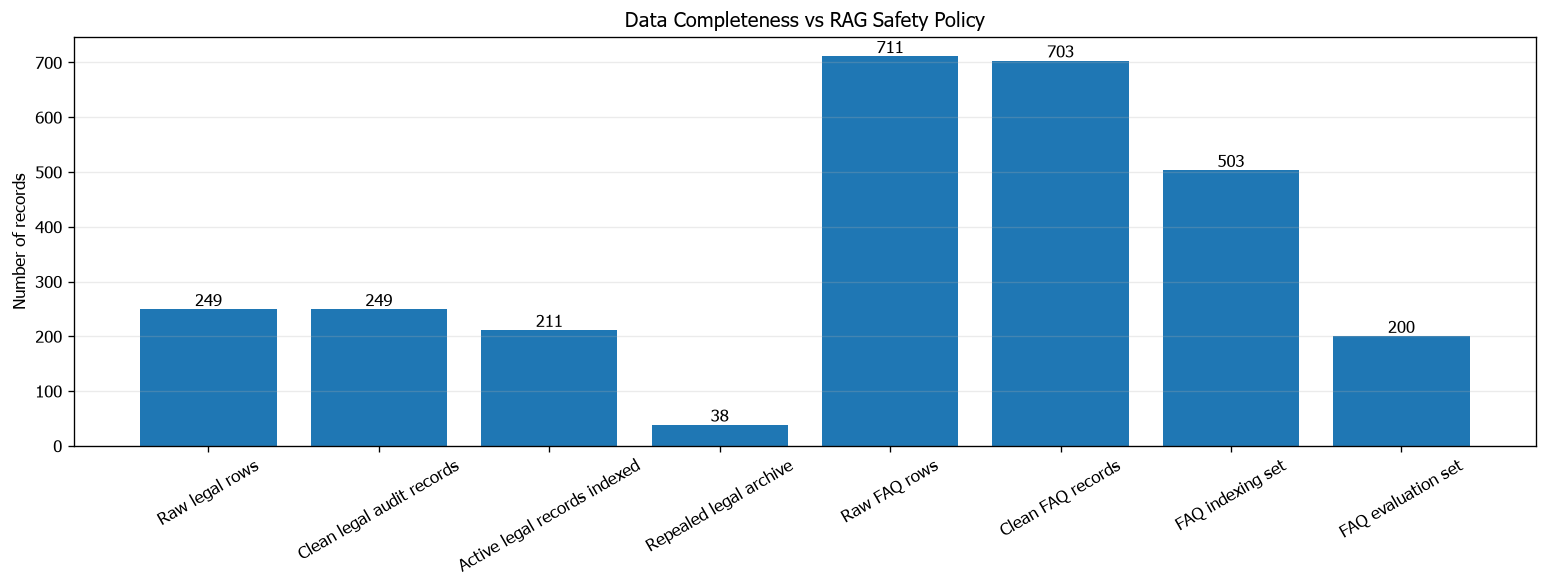

Saved figure: saudi_labor_law_voice_agent_project\05_reports\figures\01_data_completeness_vs_rag_safety_policy.png
Interpretation: audit completeness is separated from retrieval safety; repealed articles are retained but not indexed.


In [23]:
# =========================================================
# Figure 1 - Data completeness vs RAG safety policy
# =========================================================

retention_df = pd.DataFrame({
    "stage": [
        "Raw legal rows",
        "Clean legal audit records",
        "Active legal records indexed",
        "Repealed legal archive",
        "Raw FAQ rows",
        "Clean FAQ records",
        "FAQ indexing set",
        "FAQ evaluation set",
    ],
    "count": [
        len(df_articles_raw),
        len(df_articles),
        len(df_articles_active),
        len(df_articles_repealed),
        len(df_faq_raw),
        len(df_faq),
        len(df_faq_indexing),
        len(df_faq_evaluation),
    ]
})

retention_df.to_csv(REPORTS_DIR / "visual_01_data_completeness_vs_rag_safety_counts.csv", index=False, encoding="utf-8-sig")
display(retention_df)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(retention_df["stage"], retention_df["count"])
add_bar_labels(ax, retention_df["count"].values)
ax.set_title("Data Completeness vs RAG Safety Policy")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)
save_current_fig("01_data_completeness_vs_rag_safety_policy.png")

print("Interpretation: audit completeness is separated from retrieval safety; repealed articles are retained but not indexed.")

### Interpretation — Data Completeness and Retrieval Safety

This figure explains the distinction between preserving the full legal dataset for auditability and restricting the retrieval corpus for safety.

All cleaned legal records are retained in the audit dataset, including repealed provisions and valid legal variants. However, the experimental RAG corpus includes only active legal articles and approved FAQ indexing records. This design reduces the risk of retrieving invalid legal content and supports a more reliable legal assistant.

The FAQ split also supports fair evaluation by keeping a separate held-out subset for testing.


,split,count
0,Indexing,503
1,Held-out evaluation,200
2,Leakage overlap,0


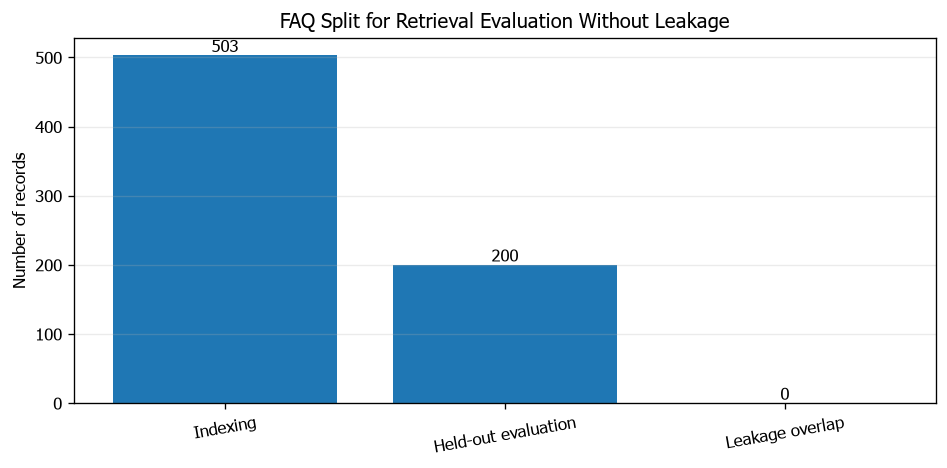

Saved figure: saudi_labor_law_voice_agent_project\05_reports\figures\05_faq_split_no_leakage.png
Interpretation: leakage overlap must be zero to avoid inflated retrieval scores.


In [24]:
# =========================================================
# Figure 5 - FAQ no-leakage split
# =========================================================

faq_leakage_overlap = len(
    set(df_faq_indexing["document_unit_id"]) &
    set(df_faq_evaluation["document_unit_id"])
)

faq_split_df = pd.DataFrame({
    "split": ["Indexing", "Held-out evaluation", "Leakage overlap"],
    "count": [len(df_faq_indexing), len(df_faq_evaluation), faq_leakage_overlap]
})

faq_split_df.to_csv(REPORTS_DIR / "visual_05_faq_split_no_leakage.csv", index=False, encoding="utf-8-sig")
display(faq_split_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(faq_split_df["split"], faq_split_df["count"])
add_bar_labels(ax, faq_split_df["count"].values)
ax.set_title("FAQ Split for Retrieval Evaluation Without Leakage")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=10)
ax.grid(axis="y", alpha=0.25)
save_current_fig("05_faq_split_no_leakage.png")

print("Interpretation: leakage overlap must be zero to avoid inflated retrieval scores.")

,strategy,chunks_count,parent_records,mean_words,median_words,max_words,chunks_per_parent_record
0,Fixed-size,719,714,83.02,68.0,500,1.007
1,Structural,722,714,85.43,72.0,653,1.011


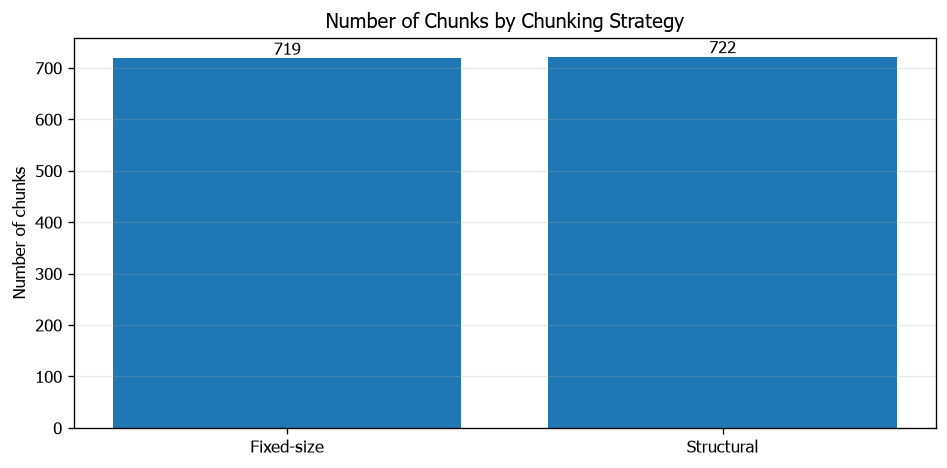

Saved figure: saudi_labor_law_voice_agent_project\05_reports\figures\08_chunks_count_by_strategy.png
Interpretation: this quantifies how chunking strategy changes the retrieval search space.


In [25]:
# =========================================================
# Figure 8 - Chunking strategy comparison
# =========================================================

chunk_strategy_df = pd.concat([
    df_structural_chunks.assign(strategy="Structural"),
    df_fixed_chunks.assign(strategy="Fixed-size"),
], ignore_index=True)

chunk_strategy_summary = (
    chunk_strategy_df
    .groupby("strategy")
    .agg(
        chunks_count=("chunk_id", "count"),
        parent_records=("parent_document_id", "nunique"),
        mean_words=("chunk_word_len", "mean"),
        median_words=("chunk_word_len", "median"),
        max_words=("chunk_word_len", "max"),
    )
    .round(2)
    .reset_index()
)

chunk_strategy_summary["chunks_per_parent_record"] = (
    chunk_strategy_summary["chunks_count"] / chunk_strategy_summary["parent_records"]
).round(3)

chunk_strategy_summary.to_csv(REPORTS_DIR / "visual_08_chunking_strategy_summary.csv", index=False, encoding="utf-8-sig")
display(chunk_strategy_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(chunk_strategy_summary["strategy"], chunk_strategy_summary["chunks_count"])
add_bar_labels(ax, chunk_strategy_summary["chunks_count"].values)
ax.set_title("Number of Chunks by Chunking Strategy")
ax.set_ylabel("Number of chunks")
ax.grid(axis="y", alpha=0.25)
save_current_fig("08_chunks_count_by_strategy.png")

print("Interpretation: this quantifies how chunking strategy changes the retrieval search space.")

,eval_type,count
0,faq_retrieval,199
1,legal_article_retrieval,24
2,out_of_scope,15


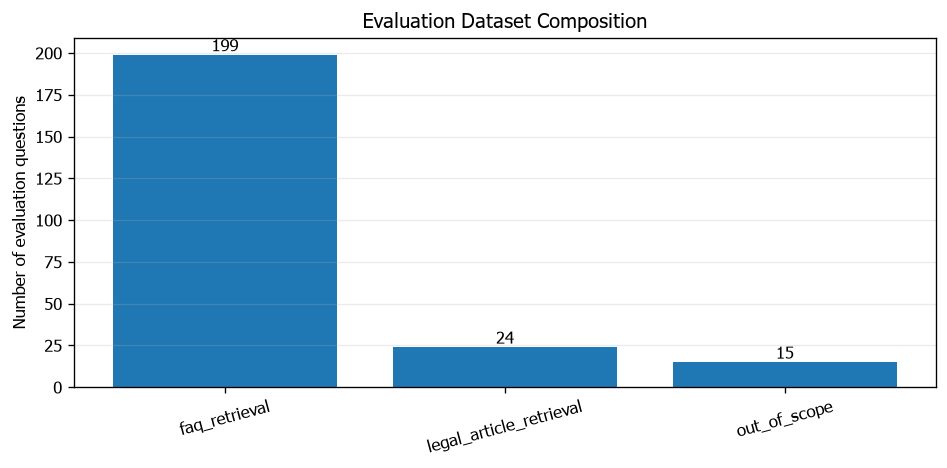

Saved figure: saudi_labor_law_voice_agent_project\05_reports\figures\10_evaluation_dataset_composition.png
Interpretation: the evaluation set combines held-out FAQ questions, manual legal questions, and out-of-scope checks.


In [26]:
# =========================================================
# Figure 10 - Evaluation dataset composition
# =========================================================

eval_comp = (
    df_eval["eval_type"]
    .value_counts()
    .rename_axis("eval_type")
    .reset_index(name="count")
)

eval_comp.to_csv(REPORTS_DIR / "visual_10_evaluation_dataset_composition.csv", index=False, encoding="utf-8-sig")
display(eval_comp)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(eval_comp["eval_type"], eval_comp["count"])
add_bar_labels(ax, eval_comp["count"].values)
ax.set_title("Evaluation Dataset Composition")
ax.set_ylabel("Number of evaluation questions")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
save_current_fig("10_evaluation_dataset_composition.png")

print("Interpretation: the evaluation set combines held-out FAQ questions, manual legal questions, and out-of-scope checks.")

,المرحلة,العدد
0,السجلات القانونية الخام,249
1,السجلات القانونية بعد التنظيف,249
2,المواد الفعالة داخل قاعدة الاسترجاع,211
3,أرشيف المواد الملغاة,38
4,الأسئلة الشائعة الخام,711
5,الأسئلة الشائعة بعد التنظيف,703
6,أسئلة الفهرسة,503
7,أسئلة التقييم,200


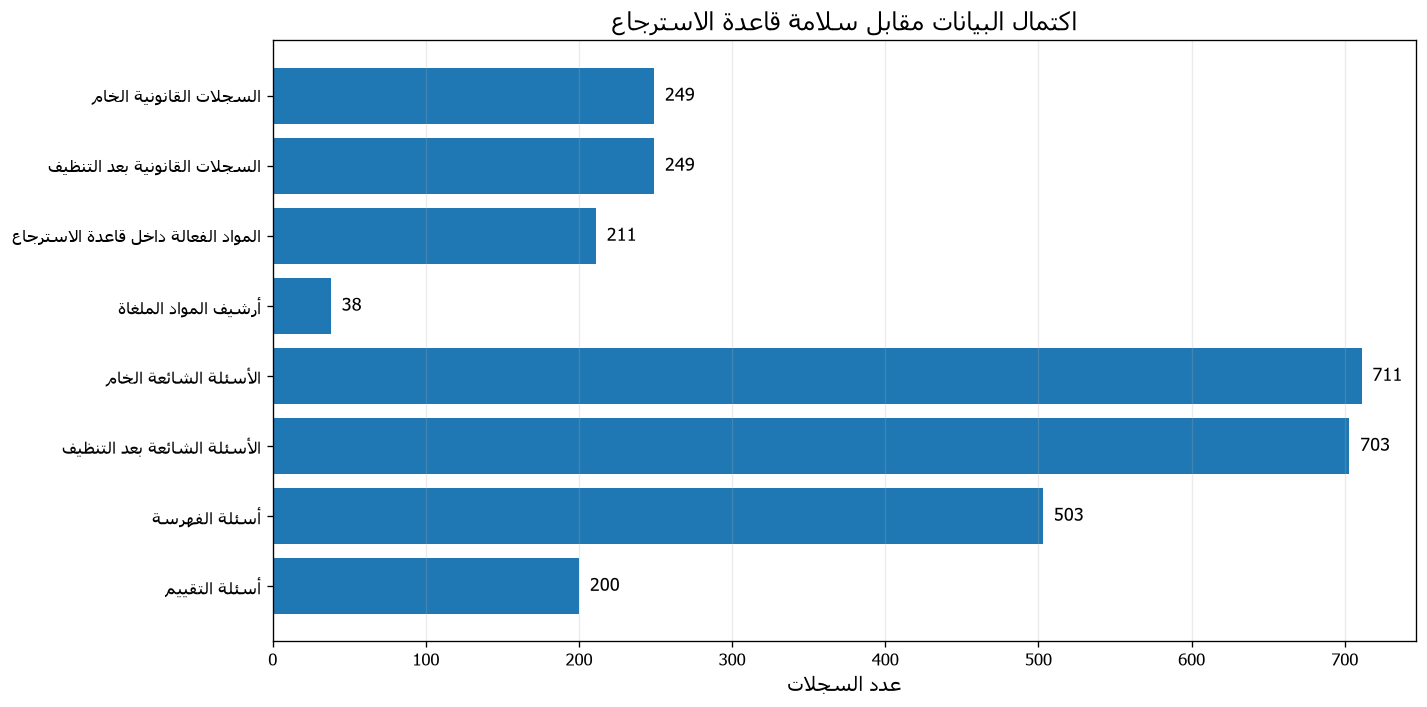

تم حفظ الرسم: saudi_labor_law_voice_agent_project\05_reports\figures\01_ar_data_completeness_vs_retrieval_safety.png


,المجموعة,العدد
0,أسئلة الفهرسة,503
1,أسئلة التقييم المعزولة,200
2,التسريب بين المجموعتين,0


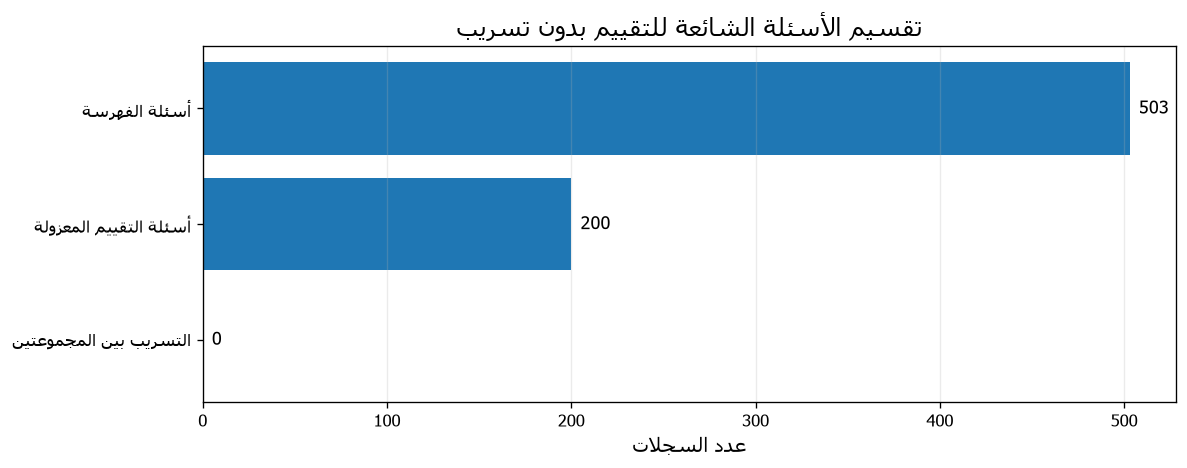

تم حفظ الرسم: saudi_labor_law_voice_agent_project\05_reports\figures\02_ar_faq_split_without_leakage.png


,الاستراتيجية,عدد المقاطع
0,التقسيم الهيكلي,722
1,التقسيم بالحجم الثابت,719


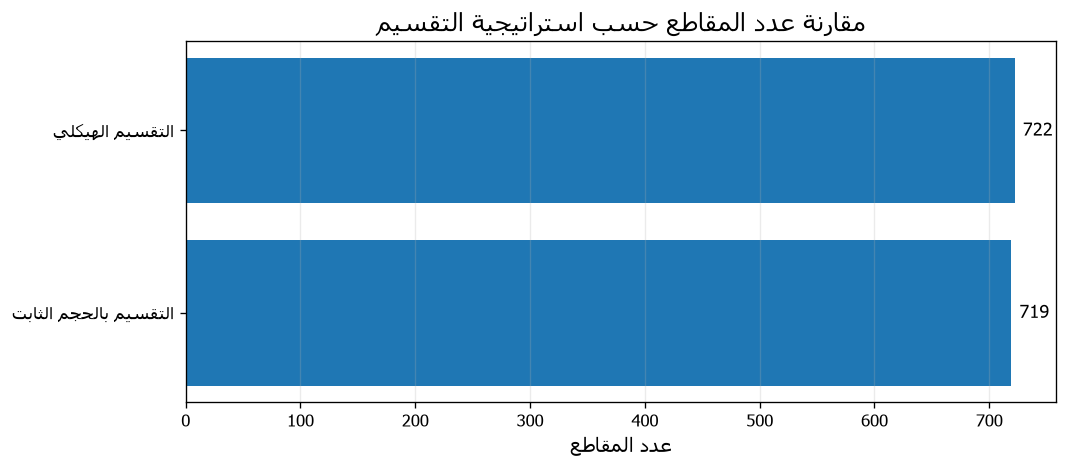

تم حفظ الرسم: saudi_labor_law_voice_agent_project\05_reports\figures\03_ar_chunking_strategy_comparison.png


,نوع التقييم,العدد
0,تقييم الأسئلة الشائعة,199
1,تقييم المواد القانونية,24
2,أسئلة خارج النطاق,15


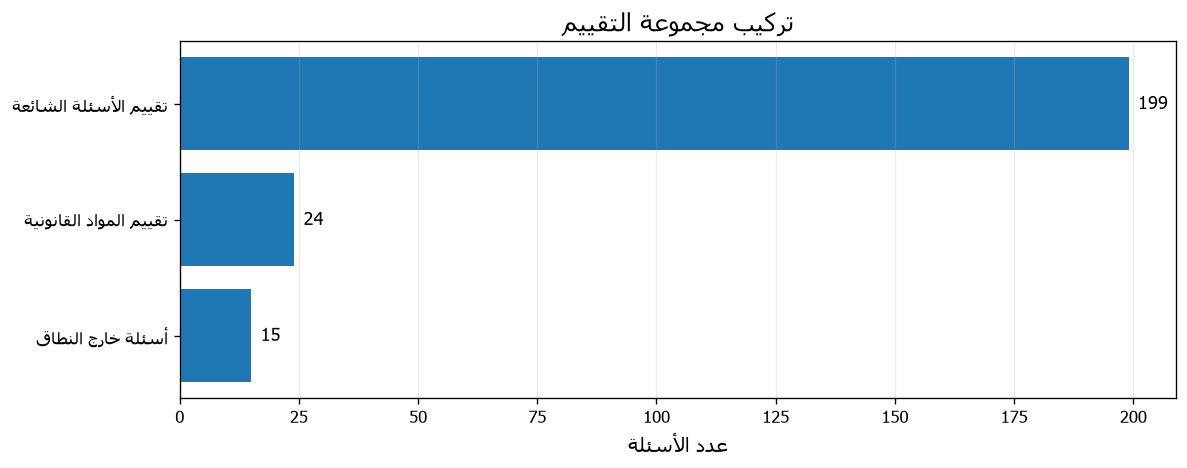

تم حفظ الرسم: saudi_labor_law_voice_agent_project\05_reports\figures\04_ar_evaluation_dataset_composition.png


In [27]:
# =========================================================
# Arabic Academic Visualisations - No Text Reversing Version
# رسومات عربية بدون قلب النص
# =========================================================

import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# مهم: لا نستخدم arabic_reshaper ولا bidi لأن بيئتك تقلب النص عند استخدامها
def ar(text):
    return str(text)

matplotlib.rcParams["font.family"] = ["Tahoma", "Arial", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False


def save_current_fig(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()
    print("تم حفظ الرسم:", path)


def add_barh_labels(ax, values):
    max_v = max(values) if len(values) else 1
    for i, v in enumerate(values):
        ax.text(
            v + max_v * 0.01,
            i,
            str(int(v)),
            va="center",
            fontsize=11
        )


# =========================================================
# Figure 1 - اكتمال البيانات مقابل سلامة قاعدة الاسترجاع
# =========================================================

retention_df_ar = pd.DataFrame({
    "المرحلة": [
        "السجلات القانونية الخام",
        "السجلات القانونية بعد التنظيف",
        "المواد الفعالة داخل قاعدة الاسترجاع",
        "أرشيف المواد الملغاة",
        "الأسئلة الشائعة الخام",
        "الأسئلة الشائعة بعد التنظيف",
        "أسئلة الفهرسة",
        "أسئلة التقييم",
    ],
    "العدد": [
        len(df_articles_raw),
        len(df_articles),
        len(df_articles_active),
        len(df_articles_repealed),
        len(df_faq_raw),
        len(df_faq),
        len(df_faq_indexing),
        len(df_faq_evaluation),
    ]
})

display(retention_df_ar)

plot_df = retention_df_ar.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(12, 6))
labels = [ar(x) for x in plot_df["المرحلة"]]
values = plot_df["العدد"].values

ax.barh(labels, values)
add_barh_labels(ax, values)

ax.set_title("اكتمال البيانات مقابل سلامة قاعدة الاسترجاع", fontsize=15)
ax.set_xlabel("عدد السجلات", fontsize=12)
ax.grid(axis="x", alpha=0.25)

save_current_fig("01_ar_data_completeness_vs_retrieval_safety.png")


# =========================================================
# Figure 2 - تقسيم الأسئلة الشائعة بدون تسريب
# =========================================================

faq_leakage_overlap = len(
    set(df_faq_indexing["document_unit_id"]) &
    set(df_faq_evaluation["document_unit_id"])
)

faq_split_df_ar = pd.DataFrame({
    "المجموعة": [
        "أسئلة الفهرسة",
        "أسئلة التقييم المعزولة",
        "التسريب بين المجموعتين",
    ],
    "العدد": [
        len(df_faq_indexing),
        len(df_faq_evaluation),
        faq_leakage_overlap,
    ]
})

display(faq_split_df_ar)

plot_df = faq_split_df_ar.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(10, 4))
labels = [ar(x) for x in plot_df["المجموعة"]]
values = plot_df["العدد"].values

ax.barh(labels, values)
add_barh_labels(ax, values)

ax.set_title("تقسيم الأسئلة الشائعة للتقييم بدون تسريب", fontsize=15)
ax.set_xlabel("عدد السجلات", fontsize=12)
ax.grid(axis="x", alpha=0.25)

save_current_fig("02_ar_faq_split_without_leakage.png")


# =========================================================
# Figure 3 - مقارنة استراتيجيات التقسيم
# =========================================================

chunking_comparison_ar = pd.DataFrame({
    "الاستراتيجية": [
        "التقسيم الهيكلي",
        "التقسيم بالحجم الثابت",
    ],
    "عدد المقاطع": [
        len(df_structural_chunks),
        len(df_fixed_chunks),
    ]
})

display(chunking_comparison_ar)

plot_df = chunking_comparison_ar.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(9, 4))
labels = [ar(x) for x in plot_df["الاستراتيجية"]]
values = plot_df["عدد المقاطع"].values

ax.barh(labels, values)
add_barh_labels(ax, values)

ax.set_title("مقارنة عدد المقاطع حسب استراتيجية التقسيم", fontsize=15)
ax.set_xlabel("عدد المقاطع", fontsize=12)
ax.grid(axis="x", alpha=0.25)

save_current_fig("03_ar_chunking_strategy_comparison.png")


# =========================================================
# Figure 4 - تركيب مجموعة التقييم
# =========================================================

eval_type_map = {
    "faq_retrieval": "تقييم الأسئلة الشائعة",
    "legal_article_retrieval": "تقييم المواد القانونية",
    "out_of_scope": "أسئلة خارج النطاق",
}

eval_comp_ar = (
    df_eval["eval_type"]
    .map(eval_type_map)
    .fillna(df_eval["eval_type"])
    .value_counts()
    .rename_axis("نوع التقييم")
    .reset_index(name="العدد")
)

display(eval_comp_ar)

plot_df = eval_comp_ar.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(10, 4))
labels = [ar(x) for x in plot_df["نوع التقييم"]]
values = plot_df["العدد"].values

ax.barh(labels, values)
add_barh_labels(ax, values)

ax.set_title("تركيب مجموعة التقييم", fontsize=15)
ax.set_xlabel("عدد الأسئلة", fontsize=12)
ax.grid(axis="x", alpha=0.25)

save_current_fig("04_ar_evaluation_dataset_composition.png")

,القطاع,عدد الأسئلة
0,قطاع العمل,271
1,قطاع الخدمة المدنية (العام),226
2,قطاع التنمية الاجتماعية,105
3,غير محدد,87
4,قطاع التنمية الاجتماعية | قطاع الخدمة المدنية (العام) | قطاع العمل,10
5,قطاع التنمية الاجتماعية | قطاع العمل,4


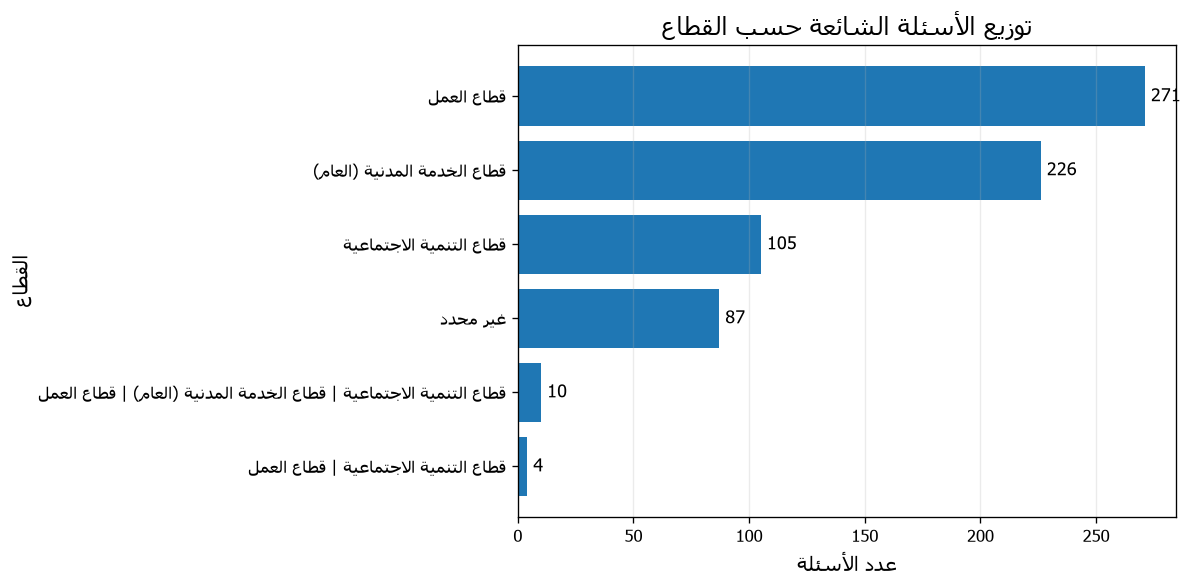

تم حفظ الرسم: saudi_labor_law_voice_agent_project\05_reports\figures\06_ar_faq_sectors_by_question_count.png
التفسير: يوضح هذا الرسم تركّز الأسئلة الشائعة حسب القطاع، ويساعد في اكتشاف عدم توازن التصنيفات داخل بيانات FAQ.


In [28]:
# =========================================================
# Figure 6 - توزيع الأسئلة الشائعة حسب القطاع
# بدون قلب النص العربي
# =========================================================

import matplotlib.pyplot as plt
import matplotlib

# لا تستخدم arabic_reshaper ولا bidi في بيئتك الحالية
matplotlib.rcParams["font.family"] = ["Tahoma", "Arial", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

faq_sector_counts = (
    df_faq["sector"]
    .replace("", "غير محدد")
    .fillna("غير محدد")
    .value_counts()
    .head(12)
    .rename_axis("القطاع")
    .reset_index(name="عدد الأسئلة")
)

faq_sector_counts.to_csv(
    REPORTS_DIR / "visual_06_faq_sector_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

display(faq_sector_counts)

# نعكس الترتيب حتى يظهر الأعلى في أعلى الرسم
plot_df = faq_sector_counts.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(10, 5))

y_labels = plot_df["القطاع"].astype(str).tolist()
values = plot_df["عدد الأسئلة"].values

ax.barh(y_labels, values)

# إضافة الأرقام بجانب الأعمدة
max_v = max(values) if len(values) else 1
for i, v in enumerate(values):
    ax.text(
        v + max_v * 0.01,
        i,
        str(int(v)),
        va="center",
        fontsize=11
    )

ax.set_title("توزيع الأسئلة الشائعة حسب القطاع", fontsize=15)
ax.set_xlabel("عدد الأسئلة", fontsize=12)
ax.set_ylabel("القطاع", fontsize=12)
ax.grid(axis="x", alpha=0.25)

save_current_fig("06_ar_faq_sectors_by_question_count.png")

print("التفسير: يوضح هذا الرسم تركّز الأسئلة الشائعة حسب القطاع، ويساعد في اكتشاف عدم توازن التصنيفات داخل بيانات FAQ.")

## Stage 15 — Final Output Files Manifest

This stage verifies that all required output files from the data preparation notebook have been successfully generated.

The manifest covers cleaned datasets, active and repealed legal article files, FAQ indexing and evaluation files, RAG knowledge-base files, chunk files, quality reports, and dataset summaries.

This final check confirms that the notebook outputs are ready to be used in the next stage: embeddings, ChromaDB indexing, and retrieval evaluation.


In [29]:
# =========================================================
# Stage 15 - Final Output Files Manifest
# فحص نهائي لجميع مخرجات مرحلة إعداد البيانات
# =========================================================

from pathlib import Path
import pandas as pd

# ---------------------------------------------------------
# 1) Final required data/report files
# ---------------------------------------------------------

output_files = [
    # Cleaned datasets
    CLEAN_DIR / "clean_labor_law_articles.csv",
    CLEAN_DIR / "clean_labor_law_articles_active_only_for_rag.csv",
    CLEAN_DIR / "clean_labor_law_articles_repealed_archive_not_indexed.csv",
    CLEAN_DIR / "clean_hrsd_faq_classified.csv",

    # Final split datasets
    FINAL_DIR / "hrsd_faq_indexing_set.csv",
    FINAL_DIR / "hrsd_faq_evaluation_set.csv",

    # Final RAG knowledge bases
    FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv",
    FINAL_DIR / "rag_knowledge_base_dataset_full_production_active_law_only.csv",

    # Legacy-compatible copies for next RAG notebook
    FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage.csv",
    FINAL_DIR / "rag_knowledge_base_dataset_full_production.csv",

    # Repealed archive
    FINAL_DIR / "legal_articles_repealed_archive_not_indexed.csv",

    # Evaluation dataset
    FINAL_DIR / "rag_evaluation_dataset.csv",

    # Chunks
    CHUNKS_DIR / "rag_chunks_structural_legal_experiment.csv",
    CHUNKS_DIR / "rag_chunks_fixed_size_experiment.csv",

    # Reports
    REPORTS_DIR / "legal_article_rag_policy_split.csv",
    REPORTS_DIR / "data_quality_report.csv",
    REPORTS_DIR / "chunk_quality_report.csv",
    REPORTS_DIR / "chunk_length_summary.csv",
    REPORTS_DIR / "dataset_summary.csv",
    REPORTS_DIR / "dataset_summary.xlsx",
    REPORTS_DIR / "dataset_summary.json",
]

# ---------------------------------------------------------
# 2) Main academic figures only
# الأربع رسومات المعتمدة أكاديمياً
# ---------------------------------------------------------

selected_figure_files = [
    FIGURES_DIR / "01_ar_data_completeness_vs_retrieval_safety.png",
    FIGURES_DIR / "02_ar_faq_split_without_leakage.png",
    FIGURES_DIR / "03_ar_chunking_strategy_comparison.png",
    FIGURES_DIR / "04_ar_evaluation_dataset_composition.png",
]

# لو كنت تستخدم النسخة الإنجليزية السابقة، أضفها كبديل إذا لم توجد العربية
fallback_figure_files = [
    FIGURES_DIR / "01_data_completeness_vs_rag_safety_policy.png",
    FIGURES_DIR / "05_faq_split_no_leakage.png",
    FIGURES_DIR / "08_chunks_count_by_strategy.png",
    FIGURES_DIR / "10_evaluation_dataset_composition.png",
]

# اختيار الرسومات العربية إن وجدت، وإلا استخدام البديل الإنجليزي
final_figure_files = []
for ar_fig, en_fig in zip(selected_figure_files, fallback_figure_files):
    if ar_fig.exists():
        final_figure_files.append(ar_fig)
    elif en_fig.exists():
        final_figure_files.append(en_fig)
    else:
        final_figure_files.append(ar_fig)  # سيظهر Missing في التقرير

# ---------------------------------------------------------
# 3) Build final manifest
# ---------------------------------------------------------

manifest_rows = []

def add_manifest_row(file_path, file_group):
    file_path = Path(file_path)
    manifest_rows.append({
        "file_group": file_group,
        "file_name": file_path.name,
        "file_path": str(file_path),
        "exists": file_path.exists(),
        "size_kb": round(file_path.stat().st_size / 1024, 2) if file_path.exists() else 0,
        "status": "OK" if file_path.exists() else "MISSING",
    })

for p in output_files:
    add_manifest_row(p, "data_or_report")

for p in final_figure_files:
    add_manifest_row(p, "main_academic_figure")

final_manifest = pd.DataFrame(manifest_rows)

# ---------------------------------------------------------
# 4) Display final status
# ---------------------------------------------------------

print("Final data/report files:")
for _, row in final_manifest[final_manifest["file_group"] == "data_or_report"].iterrows():
    icon = "✅" if row["exists"] else "❌"
    print(icon, row["file_path"])

print("\nMain academic figures:")
for _, row in final_manifest[final_manifest["file_group"] == "main_academic_figure"].iterrows():
    icon = "✅" if row["exists"] else "❌"
    print(icon, row["file_path"])

print("\nSummary:")
print("Total expected files:", len(final_manifest))
print("Existing files:", int(final_manifest["exists"].sum()))
print("Missing files:", int((~final_manifest["exists"]).sum()))

display(final_manifest)

# ---------------------------------------------------------
# 5) Save final manifest
# ---------------------------------------------------------

final_manifest.to_csv(
    REPORTS_DIR / "final_output_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

final_manifest.to_excel(
    REPORTS_DIR / "final_output_manifest.xlsx",
    index=False
)

# ---------------------------------------------------------
# 6) Safety assertion
# ---------------------------------------------------------

missing_files = final_manifest[~final_manifest["exists"]]

if len(missing_files) > 0:
    print("\nMissing files found:")
    display(missing_files)
else:
    print("\nAll final output files were generated successfully.")

assert missing_files.empty, "Some final output files are missing. Please review the manifest above."

Final data/report files:
✅ saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles.csv
✅ saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_active_only_for_rag.csv
✅ saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_repealed_archive_not_indexed.csv
✅ saudi_labor_law_voice_agent_project\02_clean\clean_hrsd_faq_classified.csv
✅ saudi_labor_law_voice_agent_project\03_final\hrsd_faq_indexing_set.csv
✅ saudi_labor_law_voice_agent_project\03_final\hrsd_faq_evaluation_set.csv
✅ saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv
✅ saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production_active_law_only.csv
✅ saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage.csv
✅ saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production.csv
✅ saudi_labor_law_voice_agent_project\03_final\legal_

,file_group,file_name,file_path,exists,size_kb,status
0,data_or_report,clean_labor_law_articles.csv,saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles.csv,True,802.42,OK
1,data_or_report,clean_labor_law_articles_active_only_for_rag.csv,saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_active_only_for_rag.csv,True,767.77,OK
2,data_or_report,clean_labor_law_articles_repealed_archive_not_indexed.csv,saudi_labor_law_voice_agent_project\02_clean\clean_labor_law_articles_repealed_archive_not_indexed.csv,True,41.62,OK
3,data_or_report,clean_hrsd_faq_classified.csv,saudi_labor_law_voice_agent_project\02_clean\clean_hrsd_faq_classified.csv,True,2369.33,OK
4,data_or_report,hrsd_faq_indexing_set.csv,saudi_labor_law_voice_agent_project\03_final\hrsd_faq_indexing_set.csv,True,1737.71,OK
5,data_or_report,hrsd_faq_evaluation_set.csv,saudi_labor_law_voice_agent_project\03_final\hrsd_faq_evaluation_set.csv,True,635.76,OK
6,data_or_report,rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage_active_law_only.csv,True,2186.34,OK
7,data_or_report,rag_knowledge_base_dataset_full_production_active_law_only.csv,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production_active_law_only.csv,True,2764.25,OK
8,data_or_report,rag_knowledge_base_dataset_experiment_no_leakage.csv,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage.csv,True,2186.34,OK
9,data_or_report,rag_knowledge_base_dataset_full_production.csv,saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_full_production.csv,True,2764.25,OK



All final output files were generated successfully.


### Interpretation — Final Output Manifest

The output manifest provides a final reproducibility check for the data preparation stage.

A successful result indicates that all core files required for the next notebook exist in the expected project directories. This reduces execution risk in later stages and makes the project easier to review, reproduce, and submit.

The most important files for the next stage are the experimental no-leakage RAG knowledge base, the enriched evaluation dataset, and the structural and fixed-size chunk files.


## Stage 16 — Readiness for the Retrieval Evaluation Stage

This stage confirms that the data preparation outputs are ready for the next phase of the project.

The next notebook will use the prepared knowledge base and chunk files to build embeddings, create or populate ChromaDB collections, and evaluate retrieval performance using metrics such as Recall@K, MRR, nDCG, article hit rate, and latency.


In [30]:
# =========================================================
# Stage 16 - Ready for Next Stage
# جاهزية مخرجات إعداد البيانات للمرحلة التالية
# =========================================================

next_stage_files = {
    "Experimental RAG Knowledge Base": FINAL_DIR / "rag_knowledge_base_dataset_experiment_no_leakage.csv",
    "Evaluation Dataset": FINAL_DIR / "rag_evaluation_dataset.csv",
    "Structural Chunks": CHUNKS_DIR / "rag_chunks_structural_legal_experiment.csv",
    "Fixed-size Chunks": CHUNKS_DIR / "rag_chunks_fixed_size_experiment.csv",
    "Repealed Legal Archive": FINAL_DIR / "legal_articles_repealed_archive_not_indexed.csv",
}

print("Data preparation stage is complete.")
print("Next stage: embeddings, vector database, retrieval experiments, and evaluation metrics.")
print("\nFiles required for the next stage:")

missing_next_stage_files = []

for name, path in next_stage_files.items():
    status = "✅" if path.exists() else "❌"
    print(status, name, "=>", path)
    if not path.exists():
        missing_next_stage_files.append((name, path))

print("\nImportant notes:")
print("- Use the experimental KB for fair evaluation.")
print("- It contains active legal articles only.")
print("- FAQ evaluation records are held out and not indexed.")
print("- Repealed legal articles are archived but excluded from RAG indexing.")

assert len(missing_next_stage_files) == 0, "Some required files for the next stage are missing."

print("\nReady for the next stage.")

Data preparation stage is complete.
Next stage: embeddings, vector database, retrieval experiments, and evaluation metrics.

Files required for the next stage:
✅ Experimental RAG Knowledge Base => saudi_labor_law_voice_agent_project\03_final\rag_knowledge_base_dataset_experiment_no_leakage.csv
✅ Evaluation Dataset => saudi_labor_law_voice_agent_project\03_final\rag_evaluation_dataset.csv
✅ Structural Chunks => saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_structural_legal_experiment.csv
✅ Fixed-size Chunks => saudi_labor_law_voice_agent_project\04_chunks\rag_chunks_fixed_size_experiment.csv
✅ Repealed Legal Archive => saudi_labor_law_voice_agent_project\03_final\legal_articles_repealed_archive_not_indexed.csv

Important notes:
- Use the experimental KB for fair evaluation.
- It contains active legal articles only.
- FAQ evaluation records are held out and not indexed.
- Repealed legal articles are archived but excluded from RAG indexing.

Ready for the next stage.


### Final Academic Summary — Stage 02

This notebook completes the data preparation and knowledge base construction stage for the Arabic Saudi Labor Law RAG project.

The stage produced a clean and auditable legal dataset, separated active and repealed legal provisions, prepared FAQ indexing and evaluation subsets, constructed safe experimental and production RAG knowledge bases, enriched the evaluation dataset with manual legal and out-of-scope questions, and generated two chunking strategies for later comparison.

The key methodological contribution of this stage is the prevention of retrieval leakage and unsafe legal retrieval. Repealed legal articles are preserved for auditability but excluded from the retrieval corpus, while FAQ evaluation records are held out from the experimental knowledge base. These decisions support a fair and academically defensible retrieval evaluation in the next stage.
